# Sustainability Project Notebook

**Group AN:** North America + Europe | **Scope:** 1 + 2

## Import Libraries and Read Investment Set CSV Files

In [86]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from scipy.optimize import minimize
import cvxpy as cp
from sklearn.covariance import LedoitWolf
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

## Part I — Standard Portfolio Allocation

### 1. Data Cleaning

In [87]:
# --- Paths ---
RAW_CSV = Path("raw_data/csv")
OUTPUT_DIR = Path("processed_data/data_cleaned")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Step 1: Load Static and filter by region ---
static = pd.read_csv(RAW_CSV / "Static_2025.csv")
regions = ["AMER", "EUR"]
static = static[static["Region"].isin(regions)].copy()
valid_isins = set(static["ISIN"].tolist())

print(f"Firms after region filter (AMER + EUR): {len(static)}")
print(f"  AMER: {(static['Region'] == 'AMER').sum()}")
print(f"  EUR:  {(static['Region'] == 'EUR').sum()}")

# --- Load all data files and filter by ISIN ---
files = {
    "RI_M":    "DS_RI_T_USD_M_2025.csv",
    "RI_Y":    "DS_RI_T_USD_Y_2025.csv",
    "MV_M":    "DS_MV_T_USD_M_2025.csv",
    "MV_Y":    "DS_MV_T_USD_Y_2025.csv",
    "CO2_S1":  "DS_CO2_SCOPE_1_Y_2025.csv",
    "CO2_S2":  "DS_CO2_SCOPE_2_Y_2025.csv",
    "REV":     "DS_REV_Y_2025.csv",
}

data = {}
for key, filename in files.items():
    df = pd.read_csv(RAW_CSV / filename)
    # Remove Datastream error rows ($$ER)
    df = df[df["ISIN"].notna() & ~df["NAME"].str.contains(r"\$\$ER", na=True)]
    # Filter by region
    df = df[df["ISIN"].isin(valid_isins)].copy()
    data[key] = df
    print(f"{key}: {len(df)} firms loaded")

# --- Step 2: Remove date columns before 2003 ---
def filter_columns_from_2003(df):
    """Keep NAME, ISIN + all date columns from 2003 onwards."""
    keep = []
    for col in df.columns:
        if col in ["NAME", "ISIN"]:
            keep.append(col)
        else:
            try:
                date = pd.to_datetime(col)
                if date.year >= 2003:
                    keep.append(col)
            except:
                keep.append(col)
    return df[keep]

print("\n--- Step 2: Remove date columns before 2003 ---")
for key in data:
    before = len(data[key].columns)
    data[key] = filter_columns_from_2003(data[key])
    after = len(data[key].columns)
    print(f"{key}: {before - after} columns removed, {after - 2} date columns kept")

# --- Step 3: Replace empty cells with NaN ---
print("\n--- Step 3: Replace empty cells with NaN ---")
for key in data:
    data[key] = data[key].fillna(float("nan"))
    print(f"{key}: empty cells replaced with NaN")

# --- Step 4: Handle delisted firms ---
print("\n--- Step 4: Handle delisted firms ---")

def get_delist_date(name):
    """Extract delisting date from firm name (e.g. 'DEAD - DELIST.10/01/22')"""
    match = re.search(r'(\d{2})/(\d{2})/(\d{2})', str(name))
    if match:
        day, month, year = int(match.group(1)), int(match.group(2)), int(match.group(3))
        year = 2000 + year if year < 50 else 1900 + year
        return pd.Timestamp(year=year, month=month, day=day)
    return None

def set_zero_after_delist(df, label):
    """Set 0 on first period after delisting, NaN on all subsequent."""
    date_cols = [c for c in df.columns if c not in ["NAME", "ISIN"]]
    dates = pd.to_datetime(date_cols)
    dead = df[df["NAME"].str.contains("DEAD", case=False, na=False)]
    count = 0
    for idx in dead.index:
        delist_date = get_delist_date(df.loc[idx, "NAME"])
        if delist_date is None:
            continue
        first_after = True
        for col, d in zip(date_cols, dates):
            if d >= delist_date:
                if first_after:
                    df.loc[idx, col] = 0
                    first_after = False
                else:
                    df.loc[idx, col] = float("nan")
        count += 1
    print(f"{label}: {count} delisted firms processed")
    return df

for key in ["RI_M", "RI_Y", "MV_M", "MV_Y"]:
    data[key] = set_zero_after_delist(data[key], key)

# --- Step 5: Forward-fill missing values between available values (CO2, REV) ---
print("\n--- Step 5: Forward-fill missing values (CO2_S1, CO2_S2, REV) ---")
for key in ["CO2_S1", "CO2_S2", "REV"]:
    date_cols = [c for c in data[key].columns if c not in ["NAME", "ISIN"]]
    before_nan = data[key][date_cols].isna().sum().sum()
    for idx in data[key].index:
        vals = data[key].loc[idx, date_cols]
        first_valid = vals.first_valid_index()
        if first_valid is not None:
            start = date_cols.index(first_valid)
            data[key].loc[idx, date_cols[start:]] = vals.iloc[start:].ffill()
    after_nan = data[key][date_cols].isna().sum().sum()
    print(f"{key}: {before_nan - after_nan} NaN filled ({before_nan} -> {after_nan})")

# --- Step 6: Replace low prices (< 0.5) with NaN (keep delisting zeros) ---
print("\n--- Step 6: Replace low prices (< 0.5) with NaN ---")
for key in ["RI_M", "RI_Y"]:
    date_cols = [c for c in data[key].columns if c not in ["NAME", "ISIN"]]
    dates = pd.to_datetime(date_cols)
    low_count = 0
    for idx in data[key].index:
        name = data[key].loc[idx, "NAME"]
        delist_date = get_delist_date(name) if "DEAD" in str(name).upper() else None
        for col, d in zip(date_cols, dates):
            val = data[key].loc[idx, col]
            if pd.notna(val) and val < 0.5:
                # Skip if this is the delisting zero
                if delist_date is not None and d >= delist_date:
                    continue
                data[key].loc[idx, col] = float("nan")
                low_count += 1
    print(f"{key}: {low_count} values < 0.5 replaced with NaN (delisting zeros kept)")

# --- Save filtered data ---
static.to_csv(OUTPUT_DIR / "Static_filtered.csv", index=False)
for key, df in data.items():
    df.to_csv(OUTPUT_DIR / f"{key}_filtered.csv", index=False)

print(f"\nFiltered data saved to {OUTPUT_DIR}/")


Firms after region filter (AMER + EUR): 1302
  AMER: 669
  EUR:  633
RI_M: 1302 firms loaded
RI_Y: 1302 firms loaded
MV_M: 1302 firms loaded
MV_Y: 1302 firms loaded
CO2_S1: 1302 firms loaded
CO2_S2: 1302 firms loaded
REV: 1302 firms loaded

--- Step 2: Remove date columns before 2003 ---
RI_M: 37 columns removed, 277 date columns kept
RI_Y: 4 columns removed, 23 date columns kept
MV_M: 37 columns removed, 277 date columns kept
MV_Y: 4 columns removed, 23 date columns kept
CO2_S1: 4 columns removed, 23 date columns kept
CO2_S2: 4 columns removed, 23 date columns kept
REV: 4 columns removed, 23 date columns kept

--- Step 3: Replace empty cells with NaN ---
RI_M: empty cells replaced with NaN
RI_Y: empty cells replaced with NaN
MV_M: empty cells replaced with NaN
MV_Y: empty cells replaced with NaN
CO2_S1: empty cells replaced with NaN
CO2_S2: empty cells replaced with NaN
REV: empty cells replaced with NaN

--- Step 4: Handle delisted firms ---
RI_M: 108 delisted firms processed
RI_Y: 1

### 2 Minimum-Variance Portfolio Allocation

#### 2.1 Investment set

In [88]:
# --- Paths ---
CLEANED_DIR = Path("processed_data/data_cleaned")
OUTPUT_DIR = Path("processed_data/data_investment_set")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Step 1: Load cleaned data and calculate monthly returns ---
print("--- Step 1: Load cleaned data and calculate monthly returns ---")
static = pd.read_csv(CLEANED_DIR / "Static_filtered.csv")
ri_m = pd.read_csv(CLEANED_DIR / "RI_M_filtered.csv")
mv_y = pd.read_csv(CLEANED_DIR / "MV_Y_filtered.csv")
co2_s1 = pd.read_csv(CLEANED_DIR / "CO2_S1_filtered.csv")
co2_s2 = pd.read_csv(CLEANED_DIR / "CO2_S2_filtered.csv")
rev = pd.read_csv(CLEANED_DIR / "REV_filtered.csv")

# Calculate monthly returns from RI_M
date_cols = [c for c in ri_m.columns if c not in ["NAME", "ISIN"]]
prices = ri_m[date_cols].apply(pd.to_numeric, errors="coerce")
returns = prices.pct_change(axis=1)
returns.insert(0, "NAME", ri_m["NAME"])
returns.insert(1, "ISIN", ri_m["ISIN"])

print(f"Returns calculated: {len(returns)} firms, {len(date_cols)-1} months")

# --- Step 2: Exclude firms with < 48 months of returns (rolling 10-year window) ---
print("\n--- Step 2: Exclude firms with < 48 months of returns ---")

return_date_cols = [c for c in returns.columns if c not in ["NAME", "ISIN"]]
return_dates = pd.to_datetime(return_date_cols)

for Y in range(2013, 2026):
    # 10-year window: Y-9 to Y (e.g. 2004-2013)
    start_year = Y - 9
    window_cols = [c for c, d in zip(return_date_cols, return_dates) if d.year >= start_year and d.year <= Y]

    # Count non-NaN returns per firm
    valid_counts = returns[window_cols].notna().sum(axis=1)

    # Firms with >= 48 months
    eligible = valid_counts >= 48
    excluded = (~eligible).sum()

    print(f"Y={Y} | Window {start_year}-{Y} | Eligible: {eligible.sum()} | Excluded: {excluded} (< 48 months)")

# --- Step 3: Exclude firms without price at end of year Y ---
print("\n--- Step 3: Exclude firms without price at end of year Y ---")

ri_date_cols = [c for c in ri_m.columns if c not in ["NAME", "ISIN"]]
ri_dates = pd.to_datetime(ri_date_cols)
ri_prices = ri_m[ri_date_cols].apply(pd.to_numeric, errors="coerce")

for Y in range(2013, 2026):
    # Find the last month of year Y (December)
    dec_cols = [c for c, d in zip(ri_date_cols, ri_dates) if d.year == Y and d.month == 12]
    if not dec_cols:
        continue
    dec_col = dec_cols[0]

    # Firms with a valid price in December of year Y
    has_price = ri_prices[dec_col].notna()
    excluded = (~has_price).sum()

    print(f"Y={Y} | With price Dec {Y}: {has_price.sum()} | Excluded: {excluded}")

# --- Step 4: Exclude stale firms (> 50% zero returns over 10-year window) ---
print("\n--- Step 4: Exclude stale firms (> 50% zero returns) ---")

for Y in range(2013, 2026):
    start_year = Y - 9
    window_cols = [c for c, d in zip(return_date_cols, return_dates) if d.year >= start_year and d.year <= Y]

    # For each firm, count % of returns = 0 among valid returns
    window_returns = returns[window_cols]
    valid_counts = window_returns.notna().sum(axis=1)
    zero_counts = (window_returns == 0).sum(axis=1)

    # % of zero returns (avoid division by 0)
    pct_zero = zero_counts / valid_counts.replace(0, 1) * 100

    # Firms with <= 50% zero returns
    not_stale = pct_zero <= 50
    excluded = (~not_stale).sum()

    print(f"Y={Y} | Not stale: {not_stale.sum()} | Excluded: {excluded} (> 50% zero returns)")

# --- Step 5: Exclude firms without carbon data or revenue at end of year Y ---
print("\n--- Step 5: Exclude firms without carbon/revenue data at end of year Y ---")

co2_s1_cols = [c for c in co2_s1.columns if c not in ["NAME", "ISIN"]]
co2_s2_cols = [c for c in co2_s2.columns if c not in ["NAME", "ISIN"]]
rev_cols = [c for c in rev.columns if c not in ["NAME", "ISIN"]]

for Y in range(2013, 2026):
    y_str = str(Y)

    # Check CO2 Scope 1
    has_s1 = co2_s1[y_str].notna() if y_str in co2_s1_cols else pd.Series(False, index=co2_s1.index)
    # Check CO2 Scope 2
    has_s2 = co2_s2[y_str].notna() if y_str in co2_s2_cols else pd.Series(False, index=co2_s2.index)
    # Check Revenue
    has_rev = rev[y_str].notna() if y_str in rev_cols else pd.Series(False, index=rev.index)

    # Need all three
    has_all = has_s1.sum(), has_s2.sum(), has_rev.sum()

    print(f"Y={Y} | S1: {has_all[0]} | S2: {has_all[1]} | REV: {has_all[2]}")

# --- Final: Combine all filters and save investment set per year Y ---
print("\n--- Final: Combine all filters and save investment set ---")

for Y in range(2013, 2026):
    start_year = Y - 9
    y_str = str(Y)

    # Step 2: >= 48 months of returns
    window_cols = [c for c, d in zip(return_date_cols, return_dates) if d.year >= start_year and d.year <= Y]
    valid_counts = returns[window_cols].notna().sum(axis=1)
    filter_returns = valid_counts >= 48

    # Step 3: Price available in December Y
    dec_cols = [c for c, d in zip(ri_date_cols, ri_dates) if d.year == Y and d.month == 12]
    filter_price = ri_prices[dec_cols[0]].notna() if dec_cols else pd.Series(True, index=ri_m.index)

    # Step 4: Not stale (<=50% zero returns)
    window_returns = returns[window_cols]
    valid = window_returns.notna().sum(axis=1)
    zeros = (window_returns == 0).sum(axis=1)
    pct_zero = zeros / valid.replace(0, 1) * 100
    filter_stale = pct_zero <= 50

    # Step 5: Carbon + Revenue available
    has_s1 = co2_s1[y_str].notna() if y_str in co2_s1_cols else pd.Series(False, index=co2_s1.index)
    has_s2 = co2_s2[y_str].notna() if y_str in co2_s2_cols else pd.Series(False, index=co2_s2.index)
    has_rev = rev[y_str].notna() if y_str in rev_cols else pd.Series(False, index=rev.index)
    filter_carbon = has_s1 & has_s2 & has_rev

    # Combine all filters
    eligible = filter_returns & filter_price & filter_stale & filter_carbon
    eligible_isins = ri_m.loc[eligible, "ISIN"].tolist()

    # Build combined dataframe
    inv_set = static[static["ISIN"].isin(eligible_isins)].copy()

    # Add MV, CO2, REV for year Y
    inv_set = inv_set.merge(mv_y[["ISIN", y_str]].rename(columns={y_str: "MV_Y"}), on="ISIN", how="left")
    inv_set = inv_set.merge(co2_s1[["ISIN", y_str]].rename(columns={y_str: "CO2_S1"}), on="ISIN", how="left")
    inv_set = inv_set.merge(co2_s2[["ISIN", y_str]].rename(columns={y_str: "CO2_S2"}), on="ISIN", how="left")
    inv_set = inv_set.merge(rev[["ISIN", y_str]].rename(columns={y_str: "REV"}), on="ISIN", how="left")

    # Add carbon intensity
    inv_set["CI"] = (inv_set["CO2_S1"] + inv_set["CO2_S2"]) / (inv_set["REV"] / 1000)

    # Add monthly returns (at the end)
    firm_returns = returns.loc[eligible, ["ISIN"] + window_cols]
    inv_set = inv_set.merge(firm_returns, on="ISIN", how="left")

    inv_set = inv_set.round(4)
    inv_set.to_csv(OUTPUT_DIR / f"investment_set_{Y}.csv", index=False)

    print(f"Y={Y} | Returns: -{(~filter_returns).sum()} | Price: -{(~filter_price).sum()} | Stale: -{(~filter_stale).sum()} | Carbon: -{(~filter_carbon).sum()} | Final: {eligible.sum()} firms")


--- Step 1: Load cleaned data and calculate monthly returns ---
Returns calculated: 1302 firms, 276 months

--- Step 2: Exclude firms with < 48 months of returns ---
Y=2013 | Window 2004-2013 | Eligible: 1270 | Excluded: 32 (< 48 months)
Y=2014 | Window 2005-2014 | Eligible: 1273 | Excluded: 29 (< 48 months)
Y=2015 | Window 2006-2015 | Eligible: 1275 | Excluded: 27 (< 48 months)
Y=2016 | Window 2007-2016 | Eligible: 1277 | Excluded: 25 (< 48 months)
Y=2017 | Window 2008-2017 | Eligible: 1280 | Excluded: 22 (< 48 months)
Y=2018 | Window 2009-2018 | Eligible: 1280 | Excluded: 22 (< 48 months)
Y=2019 | Window 2010-2019 | Eligible: 1283 | Excluded: 19 (< 48 months)
Y=2020 | Window 2011-2020 | Eligible: 1284 | Excluded: 18 (< 48 months)
Y=2021 | Window 2012-2021 | Eligible: 1286 | Excluded: 16 (< 48 months)
Y=2022 | Window 2013-2022 | Eligible: 1286 | Excluded: 16 (< 48 months)
Y=2023 | Window 2014-2023 | Eligible: 1288 | Excluded: 14 (< 48 months)
Y=2024 | Window 2015-2024 | Eligible: 1287

In [89]:
# --- Paths ---
INV_SET_DIR = Path("processed_data/data_investment_set")
OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Investment Set Statistics
print("--- Step 1: Estimate parameters (mu, sigma) ---")

for Y in range(2013, 2026):
    # Load investment set for year Y
    inv = pd.read_csv(INV_SET_DIR / f"investment_set_{Y}.csv")

    # Identify return columns (dates)
    info_cols = ["ISIN", "NAME", "Country", "Region", "MV_Y", "CO2_S1", "CO2_S2", "REV", "Carbon_Intensity"]
    return_cols = [c for c in inv.columns if c not in info_cols]

    # Extract returns matrix: rows = months, columns = firms
    R = inv[return_cols].T.astype(float)
    R.columns = inv["ISIN"]

    # Drop months where all values are NaN
    R = R.dropna(how="all")

    # Estimate mean returns (mu) and covariance matrix (sigma)
    mu = R.mean()
    sigma = R.cov()

    # Annualize
    mu_annual = mu * 12
    sigma_annual = sigma * 12

    # Summary
    print(f"Y={Y} | Firms: {len(inv)} | Months: {len(R)} | "
          f"Avg annual return: {mu_annual.mean():.4f} | "
          f"Avg annual vol: {np.sqrt(np.diag(sigma_annual)).mean():.4f}")


--- Step 1: Estimate parameters (mu, sigma) ---
Y=2013 | Firms: 803 | Months: 121 | Avg annual return: 28.5700 | Avg annual vol: 89.5419
Y=2014 | Firms: 834 | Months: 121 | Avg annual return: 28.9429 | Avg annual vol: 91.2265
Y=2015 | Firms: 869 | Months: 121 | Avg annual return: 29.5044 | Avg annual vol: 92.0702
Y=2016 | Firms: 889 | Months: 121 | Avg annual return: 32.7349 | Avg annual vol: 102.6318
Y=2017 | Firms: 924 | Months: 121 | Avg annual return: 32.6677 | Avg annual vol: 102.5110
Y=2018 | Firms: 980 | Months: 121 | Avg annual return: 28.1499 | Avg annual vol: 88.5661
Y=2019 | Firms: 1074 | Months: 121 | Avg annual return: 25.6868 | Avg annual vol: 80.8805
Y=2020 | Firms: 1121 | Months: 121 | Avg annual return: 25.2711 | Avg annual vol: 79.2293
Y=2021 | Firms: 1159 | Months: 121 | Avg annual return: 27.7912 | Avg annual vol: 86.8830
Y=2022 | Firms: 1160 | Months: 121 | Avg annual return: 24.3211 | Avg annual vol: 76.3125
Y=2023 | Firms: 1146 | Months: 121 | Avg annual return: 

#### Risk-Free Rate

In [90]:
risk_free_rate_2000_2025 = pd.read_csv('raw_data/csv/Risk_Free_Rate_2025.csv')
risk_free_rate_2000_2025.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)

# Transformation of the date to timestamp
risk_free_rate_2000_2025['Date'] = pd.to_datetime(risk_free_rate_2000_2025['Date'], format='%Y%m')

# Set the RF values in real numbers, not %
risk_free_rate_2000_2025['RF'] = risk_free_rate_2000_2025['RF']/100

# We will only consider data from 2014 to 2025
remove_years = (risk_free_rate_2000_2025['Date'].dt.year >= 2014)

# Apply the mask to create the new DataFrame
risk_free_rate_2014_2025 = risk_free_rate_2000_2025[remove_years].copy()

# Computation of the cumulative_return over the period
risk_free_rate_2014_2025['Cumulative Rate'] = risk_free_rate_2014_2025['RF'].add(1).cumprod()

risk_free_rate_2014_2025.set_index('Date', inplace=True)

# Store as csv file 
risk_free_rate_2014_2025.to_csv('processed_data/data_cleaned/Risk_Free_Rate_2014_2025.csv')

risk_free_rate_2014_2025


,RF,Cumulative Rate
Date,,
2014-01-01,0.0000,1.000000
2014-02-01,0.0000,1.000000
2014-03-01,0.0000,1.000000
2014-04-01,0.0000,1.000000
2014-05-01,0.0000,1.000000
...,...,...
2025-08-01,0.0038,1.216510
2025-09-01,0.0033,1.220525
2025-10-01,0.0037,1.225041


##### Loading Investment Sets

In [91]:
# Each is_yyyy dataframe contains data for the monthly returns of the last 10 years. 
# is_2013 is the investment set used for building the 2014 portfolio as it contains returns from Jan. 2004 to Dec. 2013.

for year in range(2013, 2026):
    exec(f'is_{year} = pd.read_csv(f"processed_data/data_investment_set/investment_set_{year}.csv")')
    print(f'is_{year} loaded successfully.')



is_2013 loaded successfully.
is_2014 loaded successfully.
is_2015 loaded successfully.
is_2016 loaded successfully.
is_2017 loaded successfully.
is_2018 loaded successfully.
is_2019 loaded successfully.
is_2020 loaded successfully.
is_2021 loaded successfully.
is_2022 loaded successfully.
is_2023 loaded successfully.
is_2024 loaded successfully.
is_2025 loaded successfully.


#### 2.3 Value-Weighted Portfolio (Full Available Returns)


##### Computation of the Value-Weighted Portfolio Weights


In [92]:
# Load monthly market capitalizations for value-weighted portfolio
mv_m = pd.read_csv('processed_data/data_cleaned/MV_M_filtered.csv')
mv_m_dates = [c for c in mv_m.columns if c not in ['NAME', 'ISIN']]
mv_m_values = mv_m.set_index('ISIN')[mv_m_dates].apply(pd.to_numeric, errors='coerce')
print(f'Monthly market caps loaded: {mv_m.shape[0]} firms, {len(mv_m_dates)} months')
mv_m_values # displaying the end-month market caps

Monthly market caps loaded: 1302 firms, 277 months


,2003-01-31 00:00:00,2003-02-28 00:00:00,2003-03-31 00:00:00,2003-04-30 00:00:00,2003-05-30 00:00:00,2003-06-30 00:00:00,2003-07-31 00:00:00,2003-08-29 00:00:00,2003-09-30 00:00:00,2003-10-31 00:00:00,...,2025-04-30 00:00:00,2025-05-30 00:00:00,2025-06-30 00:00:00,2025-07-31 00:00:00,2025-08-29 00:00:00,2025-09-30 00:00:00,2025-10-31 00:00:00,2025-11-28 00:00:00,2025-12-31 00:00:00,2026-01-30 00:00:00
ISIN,,,,,,,,,,,,,,,,,,,,,
AN8068571086,21890.91,24161.29,22132.30,24414.82,28310.25,27698.86,26243.16,28828.47,28335.48,27498.29,...,45225.37,44953.31,45672.20,50485.00,55025.62,51346.14,53870.88,54139.78,57390.82,72344.13
AT000000STR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10388.23,10401.63,11199.05,11149.77,10862.57,10779.54,9264.69,10577.86,11246.32,12306.47
AT00000VIE62,758.36,760.52,709.00,732.59,769.34,763.30,787.56,782.28,846.17,855.90,...,5118.09,5187.75,5265.38,5134.06,5171.66,5152.17,5118.89,5381.01,5504.78,5496.28
AT0000606306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8779.67,10038.00,9992.86,9577.98,10926.81,11340.09,12277.75,13337.81,14795.93,16701.97
AT0000652011,3986.94,3983.82,4247.52,4709.29,5039.95,5259.73,5218.55,5482.46,6019.83,6580.68,...,27742.41,33019.46,34839.85,37847.27,39064.63,40132.12,42523.17,44853.29,49610.20,53477.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
US98421M1062,6533.71,6662.88,6451.70,7311.92,8105.41,7853.27,8540.66,8524.84,8124.45,8314.49,...,554.73,615.11,663.00,509.61,500.80,481.35,425.09,355.95,303.46,280.42
US9884981013,6883.87,6984.37,7136.90,7224.27,8177.76,8645.73,8784.60,8702.41,8693.61,10042.38,...,41822.32,40010.20,41194.04,40073.70,40789.41,42185.42,38374.39,42539.18,42003.31,43174.99
US9892071054,1491.41,1684.17,1719.42,1853.89,2029.08,2092.48,2443.92,2533.71,2432.58,2703.02,...,12729.86,14736.06,15675.87,17237.52,16122.49,15077.14,13640.27,12804.38,12301.32,11904.14


In [93]:
# Calculation of the end-year weights for each investment set
for year in range(2013, 2026):
    is_yyyy = globals()[f'is_{year}']

    # Creation of the new column 'MV_Y_weight'
    is_yyyy['MV_Y_weight'] = is_yyyy['MV_Y'] / is_yyyy['MV_Y'].sum()

    # Relocation of 'MV_Y_weight' to the sixth position
    cols = list(is_yyyy.columns)
    cols.remove('MV_Y_weight')
    cols.insert(5, 'MV_Y_weight') # Set the weight column as the 6th column
    globals()[f'is_{year}'] = is_yyyy[cols]

    # Sum of weights to verify that it equals 1
    print(f"Sum of weights for {year}: {is_yyyy['MV_Y_weight'].sum()}")

# (Display of is_2013 to verify the new column and its position)
is_2013

Sum of weights for 2013: 0.9999999999999999
Sum of weights for 2014: 1.0
Sum of weights for 2015: 1.0
Sum of weights for 2016: 1.0
Sum of weights for 2017: 1.0
Sum of weights for 2018: 1.0
Sum of weights for 2019: 1.0
Sum of weights for 2020: 0.9999999999999999
Sum of weights for 2021: 1.0
Sum of weights for 2022: 1.0
Sum of weights for 2023: 1.0
Sum of weights for 2024: 1.0000000000000002
Sum of weights for 2025: 1.0


/var/folders/b3/wvshm2ws24dc4b18w65382sh0000gn/T/ipykernel_8778/1307408729.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  is_yyyy['MV_Y_weight'] = is_yyyy['MV_Y'] / is_yyyy['MV_Y'].sum()


,ISIN,NAME,Country,Region,MV_Y,MV_Y_weight,CO2_S1,CO2_S2,REV,CI,...,2013-03-29 00:00:00,2013-04-30 00:00:00,2013-05-31 00:00:00,2013-06-28 00:00:00,2013-07-31 00:00:00,2013-08-30 00:00:00,2013-09-30 00:00:00,2013-10-31 00:00:00,2013-11-29 00:00:00,2013-12-31 00:00:00
0,AN8068571086,SLB,US,AMER,105861.90,0.005598,1790000.0,430000.0,42149000.0,52.6703,...,-0.0380,-0.0061,-0.0188,-0.0146,0.1349,-0.0010,0.0917,0.0607,-0.0566,0.0227
1,AT000000STR1,STRABAG SE,AT,EUR,3087.59,0.000163,968759.0,295141.0,17782013.0,71.0774,...,-0.0889,0.0266,-0.0669,-0.0270,0.0828,-0.0430,0.1655,0.0549,0.1161,-0.0004
2,AT0000606306,RAIFFEISEN BANK INTL.,AT,EUR,8185.61,0.000433,5161.0,43060.0,13350128.0,3.6120,...,-0.1008,0.0375,-0.0315,-0.1490,0.1007,0.1284,-0.0434,0.1239,0.0031,-0.0436
3,AT0000652011,ERSTE GROUP BANK,AT,EUR,13245.36,0.000700,32753.0,84281.0,16802146.0,6.9654,...,-0.1350,0.1245,0.0511,-0.1794,0.1433,0.0550,-0.0113,0.1167,-0.0010,-0.0106
4,AT0000720008,TELEKOM AUSTRIA,AT,EUR,3381.96,0.000179,27476.0,195246.0,5930020.0,37.5584,...,-0.0064,0.0442,-0.0014,-0.0686,0.0974,0.0339,0.1697,-0.0169,0.0330,-0.1099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
798,US98389B1008,XCEL ENERGY,US,AMER,13656.38,0.000722,56535330.0,774475.0,10128223.0,5658.4265,...,0.0446,0.0704,-0.0966,-0.0038,0.0568,-0.0678,-0.0009,0.0453,-0.0291,0.0071
799,US9839191015,XILINX DEAD - DELIST.15/02/22,US,AMER,9719.62,0.000514,1685.0,26545.0,2195457.0,12.8584,...,0.0241,-0.0068,0.0794,-0.0256,0.1787,-0.0650,0.0790,-0.0304,-0.0166,0.0335
800,US98421M1062,XEROX HOLDINGS,US,AMER,9815.17,0.000519,127000.0,186000.0,22390000.0,13.9795,...,0.0675,-0.0023,0.0245,0.0385,0.0695,0.0289,0.0367,-0.0340,0.1449,0.0744
801,US9884981013,YUM! BRANDS,US,AMER,29787.74,0.001575,156510.0,2377372.0,13633000.0,185.8639,...,0.0987,-0.0483,-0.0054,0.0235,0.0565,-0.0398,0.0196,-0.0475,0.1488,-0.0267


In [94]:
# Helper function: build a returns DataFrame with years as index and months as columns
def create_returns_dataframe(returns_dict):
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    returns_df = pd.DataFrame(index=sorted(returns_dict.keys()), columns=months)
    for year, returns in returns_dict.items():
        returns_df.loc[year] = returns.values
    return returns_df


##### Value-Weighted Portfolio — Firms with 10 Years of Available Data

In [95]:
# Drop rows (assets) with any NaN to get assets with full available data (fa universe)
for year in range(2013, 2026):
    globals()[f'is_{year}_fa'] = globals()[f'is_{year}'].dropna(axis=0).copy()
    # Renormalize MV_Y_weight after dropping NaN rows so it sums to 1
    globals()[f'is_{year}_fa']['MV_Y_weight'] = (
        globals()[f'is_{year}_fa']['MV_Y_weight'] / globals()[f'is_{year}_fa']['MV_Y_weight'].sum()
    )

# Print number of assets per year
for year in range(2013, 2026):
    print(f"Number of assets with full available data for {year}: {len(globals()[f'is_{year}_fa'])}")


Number of assets with full available data for 2013: 751
Number of assets with full available data for 2014: 795
Number of assets with full available data for 2015: 846
Number of assets with full available data for 2016: 878
Number of assets with full available data for 2017: 914
Number of assets with full available data for 2018: 968
Number of assets with full available data for 2019: 1062
Number of assets with full available data for 2020: 1109
Number of assets with full available data for 2021: 1147
Number of assets with full available data for 2022: 1147
Number of assets with full available data for 2023: 1136
Number of assets with full available data for 2024: 1120
Number of assets with full available data for 2025: 1101


In [96]:
# Build value_weighted_portfolio_{year}_fa for every year with the same logic
# MV_Y_weight is already renormalized over the fa universe (done in cell above)

mv_dates_ts = pd.to_datetime(mv_m_dates)
value_weighted_returns_fa = {}

for year in range(2014, 2026):
    is_prev_fa = globals()[f'is_{year-1}_fa']  # MV_Y_weight already renormalized
    is_yyyy    = globals()[f'is_{year}']

    # Build the portfolio dataframe
    vw_fa = is_prev_fa[['ISIN', 'NAME', 'MV_Y_weight']].copy()
    ret_cols_yyyy = list(is_yyyy.columns[-12:])
    vw_fa = vw_fa.merge(is_yyyy[['ISIN'] + ret_cols_yyyy], on='ISIN', how='left')

    # Add 11 monthly weight columns (Jan–Nov)
    isins_fa    = vw_fa['ISIN'].values
    mv_cap_cols = ret_cols_yyyy[:11]
    insert_pos  = vw_fa.columns.tolist().index('MV_Y_weight') + 1

    for i, ret_col in enumerate(mv_cap_cols):
        ret_date = pd.to_datetime(ret_col)
        diffs = abs(mv_dates_ts - ret_date)
        closest_mv_col = mv_m_dates[diffs.argmin()]
        caps = mv_m_values.reindex(isins_fa)[closest_mv_col].fillna(0)
        weights = caps / caps.sum()
        col_name = f'MV_M_weight_{ret_date.strftime("%Y-%m-%d")}'
        vw_fa.insert(insert_pos + i, col_name, weights.values)

    globals()[f'value_weighted_portfolio_{year}_fa'] = vw_fa

    # Verify weights sum to 1 for all 12 months
    mvm_cols = [c for c in vw_fa.columns if c.startswith('MV_M_weight')]
    weight_cols_all = ['MV_Y_weight'] + mvm_cols
    sums = vw_fa[weight_cols_all].sum()
    print(f"{year} — weight column sums:")
    print(sums.to_string())
    print()

    # Compute monthly returns
    vw_fa_idx          = vw_fa.set_index('ISIN')
    ret_cols_sorted    = sorted(ret_cols_yyyy, key=lambda c: pd.to_datetime(c))
    mvm_cols_sorted    = sorted(mvm_cols,       key=lambda c: pd.to_datetime(c.replace('MV_M_weight_', '')))
    weight_cols_sorted = ['MV_Y_weight'] + mvm_cols_sorted

    monthly_returns = {}
    for weight_col, ret_col in zip(weight_cols_sorted, ret_cols_sorted):
        weights = vw_fa_idx[weight_col]
        rets    = vw_fa_idx[ret_col].fillna(0)
        monthly_returns[ret_col] = (weights * rets).sum()

    value_weighted_returns_fa[year] = pd.Series(monthly_returns)

# Number of assets per year in the fa universe
for year in range(2013, 2026):
    print(f"Number of assets with full available data for {year}: {len(globals()[f'is_{year}_fa'])}")

print(value_weighted_portfolio_2023_fa)
value_weighted_portfolio_returns_fa_df = create_returns_dataframe(value_weighted_returns_fa)
value_weighted_portfolio_returns_fa_df


2014 — weight column sums:
MV_Y_weight               1.0
MV_M_weight_2014-01-31    1.0
MV_M_weight_2014-02-28    1.0
MV_M_weight_2014-03-31    1.0
MV_M_weight_2014-04-30    1.0
MV_M_weight_2014-05-30    1.0
MV_M_weight_2014-06-30    1.0
MV_M_weight_2014-07-31    1.0
MV_M_weight_2014-08-29    1.0
MV_M_weight_2014-09-30    1.0
MV_M_weight_2014-10-31    1.0
MV_M_weight_2014-11-28    1.0

2015 — weight column sums:
MV_Y_weight               1.0
MV_M_weight_2015-01-30    1.0
MV_M_weight_2015-02-27    1.0
MV_M_weight_2015-03-31    1.0
MV_M_weight_2015-04-30    1.0
MV_M_weight_2015-05-29    1.0
MV_M_weight_2015-06-30    1.0
MV_M_weight_2015-07-31    1.0
MV_M_weight_2015-08-31    1.0
MV_M_weight_2015-09-30    1.0
MV_M_weight_2015-10-30    1.0
MV_M_weight_2015-11-30    1.0

2016 — weight column sums:
MV_Y_weight               1.0
MV_M_weight_2016-01-29    1.0
MV_M_weight_2016-02-29    1.0
MV_M_weight_2016-03-31    1.0
MV_M_weight_2016-04-29    1.0
MV_M_weight_2016-05-31    1.0
MV_M_weight_2016-

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2014,-0.037438,0.054852,0.007691,0.015656,0.016803,0.011617,-0.022871,0.024318,-0.023043,0.004485,0.027266,-0.01794
2015,-0.023213,0.057314,-0.018919,0.022297,0.002932,-0.023763,0.019577,-0.063806,-0.030285,0.075218,-0.005249,-0.023011
2016,-0.05472,-0.007885,0.070245,0.013489,0.006601,-0.013786,0.037111,0.002254,0.002258,-0.021259,0.01833,0.033174
2017,0.014604,0.028468,0.014131,0.018469,0.026707,0.002273,0.02243,0.00237,0.02822,0.018924,0.021923,0.013294
2018,0.047263,-0.047129,-0.018105,0.012549,0.001336,0.000174,0.038627,0.009037,0.006819,-0.064754,0.010909,-0.078357
2019,0.080055,0.033315,0.014743,0.037778,-0.060241,0.070482,0.004422,-0.018529,0.024529,0.022351,0.030266,0.034818
2020,-0.013994,-0.087877,-0.130817,0.107567,0.04152,0.028696,0.048832,0.065659,-0.038069,-0.036083,0.128596,0.039922
2021,-0.012258,0.027281,0.045175,0.050185,0.020007,0.00917,0.018795,0.02289,-0.044741,0.063694,-0.01484,0.052689
2022,-0.036754,-0.024425,0.02735,-0.072441,0.005749,-0.085884,0.079159,-0.043296,-0.091635,0.085967,0.070143,-0.042391
2023,0.078227,-0.022263,0.031204,0.026541,-0.018268,0.060776,0.028917,-0.022532,-0.046466,-0.021683,0.09052,0.045122


#### 2.2 Minimum-Variance Portfolio (Ledoit-Wolf Covariance)

In [97]:
# ── Minimum-Variance Portfolio (Ledoit-Wolf covariance, long-only, no short-selling) ──
# Uses the fa (full-available-data) universe for each year.
# Weights are determined at end-of-year Y and applied to returns over year Y+1.
# Month-by-month weight drift follows the spec: alpha_{i,t+k} = alpha_{i,t+k-1} * (1+R_{i,t+k}) / (1+R_{p,t+k})

INV_SET_DIR = Path("processed_data/data_investment_set")

mv_returns_fa   = {}   # year → pd.Series of 12 monthly portfolio returns
mv_weights_fa   = {}   # year → dict{isin: weight} at end of estimation year
mv_opt_results  = {}   # year → optimisation diagnostics

for year in range(2014, 2026):
    estimation_year = year - 1          # e.g. estimation on 2013 data → portfolio for 2014
    is_est = globals()[f'is_{estimation_year}_fa']   # fa universe (no NaN rows)

    # ── identify return columns in the estimation set ──
    non_ret_cols = ['ISIN', 'NAME', 'Country', 'Region', 'MV_Y', 'MV_Y_weight',
                    'CO2_S1', 'CO2_S2', 'REV', 'CI']
    ret_cols_est = [c for c in is_est.columns if c not in non_ret_cols]

    # ── returns matrix: T×N (rows = months, cols = assets) ──
    R_mat = is_est.set_index('ISIN')[ret_cols_est].T.astype(float)
    R_mat = R_mat.dropna(how='all')          # drop all-NaN months
    R_mat = R_mat.fillna(0)                  # remaining NaN → 0 (missing within window)
    isins_est = R_mat.columns.tolist()
    N = len(isins_est)

    # ── Ledoit-Wolf covariance (monthly, then annualise) ──
    lw = LedoitWolf()
    lw.fit(R_mat.values)
    Sigma_monthly = lw.covariance_                   # N×N monthly covariance
    Sigma = Sigma_monthly                             # optimise on monthly scale (consistent with σ²_p)

    # ── Optimisation: min α'Σα  s.t. Σα=1, α≥0 ──
    alpha0 = np.ones(N) / N

    def port_var(alpha):
        return alpha @ Sigma @ alpha

    def port_var_grad(alpha):
        return 2 * Sigma @ alpha

    constraints = [{'type': 'eq', 'fun': lambda a: np.sum(a) - 1}]
    bounds = [(0, None)] * N

    res = minimize(port_var, alpha0,
                   jac=port_var_grad,
                   method='SLSQP',
                   bounds=bounds,
                   constraints=constraints,
                   options={'ftol': 1e-12, 'maxiter': 1000})

    alpha_opt = res.x
    alpha_opt = np.maximum(alpha_opt, 0)
    alpha_opt /= alpha_opt.sum()          # re-normalise for numerical precision

    mv_weights_fa[estimation_year] = dict(zip(isins_est, alpha_opt))
    mv_opt_results[year] = {'success': res.success, 'port_vol_monthly': np.sqrt(res.fun)}

    # ── Out-of-sample returns for year Y ──
    is_next = globals()[f'is_{year}']
    ret_cols_next = list(is_next.columns[-12:])
    ret_next = is_next.set_index('ISIN')[ret_cols_next].astype(float)

    # Month-by-month weight drift
    alpha_t = np.array([mv_weights_fa[estimation_year].get(isin, 0.0) for isin in ret_next.index])
    monthly_returns = {}

    for k, ret_col in enumerate(sorted(ret_cols_next, key=lambda c: pd.to_datetime(c))):
        r_vec = ret_next[ret_col].fillna(0).values
        R_p   = float(alpha_t @ r_vec)
        monthly_returns[ret_col] = R_p
        # Drift weights for next month
        alpha_t = alpha_t * (1 + r_vec) / (1 + R_p)
        alpha_t = np.maximum(alpha_t, 0)
        if alpha_t.sum() > 0:
            alpha_t /= alpha_t.sum()

    mv_returns_fa[year] = pd.Series(monthly_returns)

    print(f"Y={year} | N={N} | Opt={'OK' if res.success else 'FAIL'} | "
          f"Monthly σ_p={mv_opt_results[year]['port_vol_monthly']*100:.3f}% | "
          f"Ann. σ_p={mv_opt_results[year]['port_vol_monthly']*np.sqrt(12)*100:.2f}%")

mv_portfolio_returns_fa_df = create_returns_dataframe(mv_returns_fa)
print("\nMonthly returns (MV portfolio):")
mv_portfolio_returns_fa_df


Y=2014 | N=751 | Opt=OK | Monthly σ_p=1.951% | Ann. σ_p=6.76%
Y=2015 | N=795 | Opt=OK | Monthly σ_p=1.981% | Ann. σ_p=6.86%
Y=2016 | N=846 | Opt=OK | Monthly σ_p=2.036% | Ann. σ_p=7.05%
Y=2017 | N=878 | Opt=OK | Monthly σ_p=2.127% | Ann. σ_p=7.37%
Y=2018 | N=914 | Opt=OK | Monthly σ_p=2.116% | Ann. σ_p=7.33%
Y=2019 | N=968 | Opt=OK | Monthly σ_p=1.872% | Ann. σ_p=6.48%
Y=2020 | N=1062 | Opt=OK | Monthly σ_p=1.655% | Ann. σ_p=5.73%
Y=2021 | N=1109 | Opt=OK | Monthly σ_p=1.838% | Ann. σ_p=6.37%
Y=2022 | N=1147 | Opt=OK | Monthly σ_p=1.873% | Ann. σ_p=6.49%
Y=2023 | N=1147 | Opt=OK | Monthly σ_p=2.060% | Ann. σ_p=7.14%
Y=2024 | N=1136 | Opt=OK | Monthly σ_p=2.001% | Ann. σ_p=6.93%
Y=2025 | N=1120 | Opt=OK | Monthly σ_p=2.048% | Ann. σ_p=7.09%

Monthly returns (MV portfolio):


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2014,-0.004525,0.048358,0.006417,0.018985,0.007476,0.007621,-0.040714,0.0297,-0.037148,0.048102,0.028482,0.007452
2015,0.004757,0.010781,-0.017159,0.0025,0.013115,-0.022853,0.048678,-0.031726,-0.006721,0.034011,-0.004797,0.022697
2016,0.003192,0.002511,0.043373,0.01013,0.012167,0.050791,0.020838,-0.044986,-0.012862,-0.033657,-0.01729,0.032693
2017,0.012957,0.018566,0.005132,0.034481,0.025452,-0.014734,0.016958,-0.041172,0.006356,0.014095,0.025405,0.015966
2018,-0.01693,-0.066727,-0.008288,0.008435,0.010887,0.020793,0.010601,0.020575,-0.00528,-0.01852,-0.004252,-0.06317
2019,0.019601,0.039007,0.036567,0.026189,-0.020282,0.041982,0.008407,0.014449,0.005981,-0.002658,0.019483,0.043381
2020,0.011816,-0.084444,-0.120684,0.111593,0.025603,-0.008946,0.073462,0.032918,-0.017497,-0.018189,0.07141,0.029353
2021,-0.005288,-0.004656,0.082699,0.024354,0.023897,-0.016775,0.028469,0.007994,-0.058525,0.035108,-0.030923,0.080285
2022,-0.017237,-0.012514,0.048897,-0.031719,0.01034,-0.054982,0.035957,-0.026596,-0.082822,0.069903,0.060175,-0.028357
2023,0.022974,-0.012161,0.011389,0.027757,-0.047265,0.016327,0.008267,-0.024506,-0.043971,-0.011027,0.034624,0.019091


=== Summary Statistics (2014–2025) ===
                 Value-Weighted (VW)  Min-Variance (MV)
Ann. Return (%)              11.6586             7.3572
Ann. Vol (%)                 14.2510            11.6522
Sharpe Ratio                  0.6949             0.4774
Min Monthly (%)             -13.0817           -12.0684
Max Monthly (%)              12.8596            11.1593
Cum. Return (%)             256.8483           122.4169


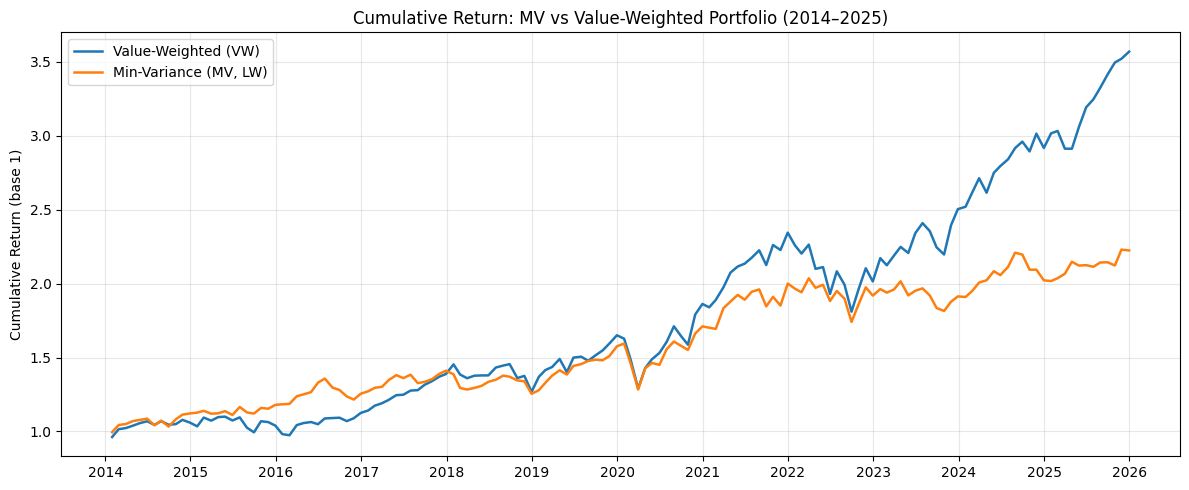

,Value-Weighted (VW),Min-Variance (MV)
Ann. Return (%),11.6586,7.3572
Ann. Vol (%),14.2510,11.6522
Sharpe Ratio,0.6949,0.4774
Min Monthly (%),-13.0817,-12.0684
Max Monthly (%),12.8596,11.1593
Cum. Return (%),256.8483,122.4169


In [98]:
# ── Helper: compute portfolio summary statistics ──
def portfolio_stats(returns_dict, rf_series):
    """
    returns_dict : {year: pd.Series of 12 monthly returns (float)}
    rf_series    : pd.Series indexed by pd.Timestamp (monthly RF)
    Returns annualised mean, vol, Sharpe, min, max (all in %).
    """
    all_rets = []
    for year in sorted(returns_dict):
        for col, val in returns_dict[year].items():
            all_rets.append((pd.to_datetime(col), val))
    all_rets.sort(key=lambda x: x[0])
    dates, rets = zip(*all_rets)
    rets = np.array(rets, dtype=float)

    # Align RF
    rf_vals = []
    for d in dates:
        closest = rf_series.index[np.argmin(np.abs(rf_series.index - d))]
        rf_vals.append(rf_series.loc[closest, 'RF'])
    rf_vals = np.array(rf_vals)

    excess = rets - rf_vals
    mu_ann   = rets.mean() * 12 * 100
    sig_ann  = rets.std(ddof=1) * np.sqrt(12) * 100
    sr       = excess.mean() / excess.std(ddof=1) * np.sqrt(12)
    r_min    = rets.min() * 100
    r_max    = rets.max() * 100
    cum_ret  = np.prod(1 + rets) - 1
    return {'Ann. Return (%)': mu_ann,
            'Ann. Vol (%)':    sig_ann,
            'Sharpe Ratio':    sr,
            'Min Monthly (%)': r_min,
            'Max Monthly (%)': r_max,
            'Cum. Return (%)': cum_ret * 100}

rf = risk_free_rate_2014_2025.copy()

stats_vw = portfolio_stats(value_weighted_returns_fa, rf)
stats_mv = portfolio_stats(mv_returns_fa, rf)

stats_df = pd.DataFrame([stats_vw, stats_mv],
                         index=['Value-Weighted (VW)', 'Min-Variance (MV)']).T.round(4)
print("=== Summary Statistics (2014–2025) ===")
print(stats_df.to_string())

# ── Cumulative return series ──
def cumulative_series(returns_dict):
    all_rets = []
    for year in sorted(returns_dict):
        for col, val in returns_dict[year].items():
            all_rets.append((pd.to_datetime(col), val))
    all_rets.sort(key=lambda x: x[0])
    dates, rets = zip(*all_rets)
    cum = np.cumprod(1 + np.array(rets, dtype=float))
    return pd.Series(cum, index=dates)

cum_vw = cumulative_series(value_weighted_returns_fa)
cum_mv = cumulative_series(mv_returns_fa)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum_vw.index, cum_vw.values, label='Value-Weighted (VW)', linewidth=1.8)
ax.plot(cum_mv.index, cum_mv.values, label='Min-Variance (MV, LW)', linewidth=1.8)
ax.set_title('Cumulative Return: MV vs Value-Weighted Portfolio (2014–2025)')
ax.set_ylabel('Cumulative Return (base 1)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

stats_df


---
## Part II — Portfolio Allocation with Carbon Emission Reduction

### 3. Carbon Metrics


=== WACI (tCO2e/M USD revenue) and CF (tCO2e/M USD invested) ===
      VW WACI  MV WACI   VW CF   MV CF
2014   196.63   772.40  178.54  390.47
2015   186.46   603.15  156.24  311.19
2016   197.40   433.97  151.26  199.65
2017   199.53   363.09  160.54  163.70
2018   210.45   380.90  137.45  167.72
2019   173.42   517.99  110.54  260.87
2020   178.17   361.78  111.95  173.12
2021   161.74   458.49   86.40  169.80
2022   159.54   306.74   79.74  131.33
2023   131.44   231.61   65.02   89.92
2024   110.30   139.04   67.57   72.06
2025   100.37   153.91   59.42   93.07


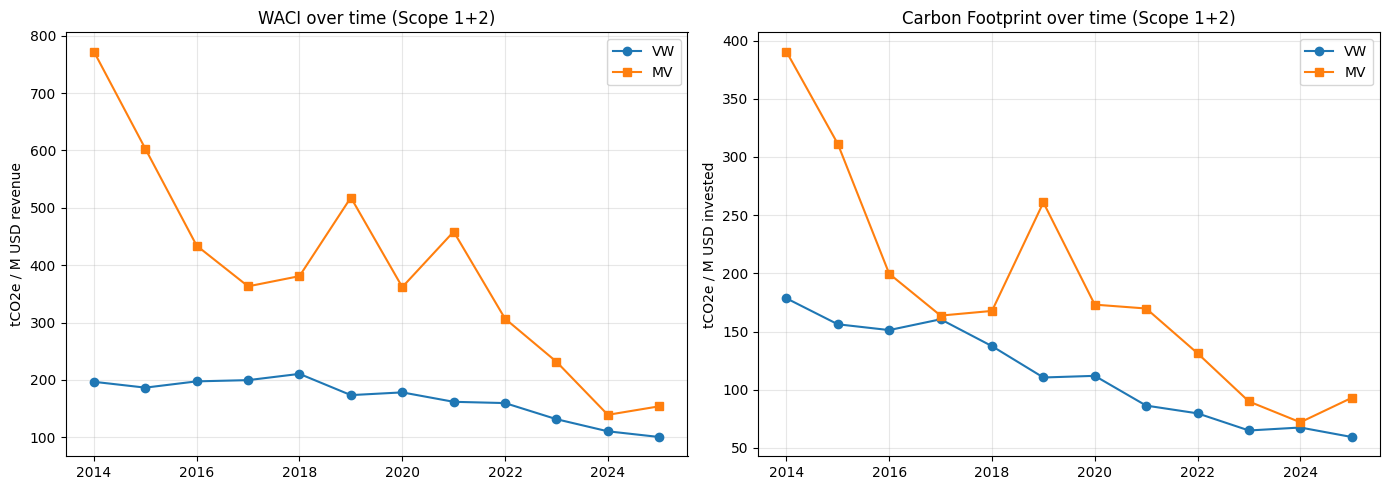


=== Top 10 Firms by Carbon Intensity (2013 investment set) ===
           ISIN                NAME          CI        CO2_S1     CO2_S2         REV
0  CA89346D1078           TRANSALTA  14123.9529  3.041750e+07   291900.0   2174278.0
1  US92939U1060    WEC ENERGY GROUP   7717.8316  3.055000e+07  2223000.0   4246400.0
2  US0255371017      AMER.ELEC.PWR.   7714.9548  1.153000e+08        0.0  14945000.0
3  US8425871071            SOUTHERN   7316.9257  1.210000e+08        0.0  16537000.0
4  US6708371033          OGE ENERGY   5795.3501  2.063066e+07   706661.0   3681800.0
5  IT0001347308               BUZZI   5670.8951  2.050000e+07  1351853.0   3853334.0
6  US6293775085          NRG ENERGY   5659.6894  5.000000e+07   292000.0   8886000.0
7  US98389B1008         XCEL ENERGY   5658.4265  5.653533e+07   774475.0  10128223.0
8  US0236081024              AMEREN   4840.1397  3.297830e+07    70179.0   6828000.0
9  US7234841010  PINNACLE WEST CAP.   4314.6748  1.422730e+07    18466.0   3301701.0


In [99]:
# ── Section 3.1: Carbon Intensity (CI), WACI, and Carbon Footprint (CF) ──
#
# Carbon Intensity: CI_{i,Y} = (CO2_S1 + CO2_S2) / (REV / 1000)   [tCO2e / M USD revenue]
#   (already computed as column 'CI' in the investment sets)
#
# WACI(p)_Y = Σ_i  α_{i,Y} * CI_{i,Y}
#
# CF(p)_Y   = (1/V_Y) * Σ_i  (V_{i,Y} / Cap_{i,Y}) * E_{i,Y}
#           = Σ_i  α_{i,Y} / Cap_{i,Y} * E_{i,Y}    [tCO2e per M USD invested]
#   where E_{i,Y} = CO2_S1 + CO2_S2  (Scope 1+2 in tonnes)
#   and   Cap_{i,Y} = MV_Y           (in million USD)

V0 = 1_000_000   # starting wealth: 1 million USD

# ── helper: build static carbon info lookup per year ──
def get_carbon_info(year):
    """Return DataFrame indexed by ISIN with columns: CI, E (=S1+S2), Cap (MV_Y)."""
    is_est = globals()[f'is_{year}_fa']
    df = is_est[['ISIN', 'MV_Y', 'CO2_S1', 'CO2_S2', 'CI']].copy().set_index('ISIN')
    df['E'] = df['CO2_S1'] + df['CO2_S2']
    return df

# ── VW portfolio carbon metrics ──
vw_waci, vw_cf = {}, {}

for year in range(2014, 2026):
    estimation_year = year - 1
    vw_port = globals()[f'value_weighted_portfolio_{year}_fa']
    carbon_info = get_carbon_info(estimation_year)

    # VW weights at start of year (Dec end-of-year Y-1 = MV_Y_weight)
    vw_port_idx = vw_port.set_index('ISIN')
    isins_common = vw_port_idx.index.intersection(carbon_info.index)

    w   = vw_port_idx.loc[isins_common, 'MV_Y_weight']
    ci  = carbon_info.loc[isins_common, 'CI']
    e   = carbon_info.loc[isins_common, 'E']
    cap = carbon_info.loc[isins_common, 'MV_Y']

    # Renormalise weights over common universe
    w_norm = w / w.sum()

    waci = (w_norm * ci).sum()
    cf   = (w_norm / cap * e).sum()   # per M USD invested (V=1 → V_i = alpha_i*1M, o_i = V_i/Cap_i)

    vw_waci[year] = waci
    vw_cf[year]   = cf   # tCO2e per M USD invested

# ── MV portfolio carbon metrics ──
mv_waci, mv_cf = {}, {}

for year in range(2014, 2026):
    estimation_year = year - 1
    carbon_info = get_carbon_info(estimation_year)

    w_dict = mv_weights_fa[estimation_year]   # {isin: alpha} at end of estimation_year
    isins_common = [isin for isin in w_dict if isin in carbon_info.index]

    w   = pd.Series({isin: w_dict[isin] for isin in isins_common})
    ci  = carbon_info.loc[isins_common, 'CI']
    e   = carbon_info.loc[isins_common, 'E']
    cap = carbon_info.loc[isins_common, 'MV_Y']

    w_norm = w / w.sum()

    waci = (w_norm * ci).sum()
    cf   = (w_norm / cap * e).sum()

    mv_waci[year] = waci
    mv_cf[year]   = cf

# ── Display ──
carbon_table = pd.DataFrame({
    'VW WACI':  pd.Series(vw_waci),
    'MV WACI':  pd.Series(mv_waci),
    'VW CF':    pd.Series(vw_cf),
    'MV CF':    pd.Series(mv_cf),
}).round(2)
print("=== WACI (tCO2e/M USD revenue) and CF (tCO2e/M USD invested) ===")
print(carbon_table.to_string())

# ── Plot WACI and CF ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

years = sorted(vw_waci.keys())
axes[0].plot(years, [vw_waci[y] for y in years], marker='o', label='VW')
axes[0].plot(years, [mv_waci[y] for y in years], marker='s', label='MV')
axes[0].set_title('WACI over time (Scope 1+2)')
axes[0].set_ylabel('tCO2e / M USD revenue')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(years, [vw_cf[y] for y in years], marker='o', label='VW')
axes[1].plot(years, [mv_cf[y] for y in years], marker='s', label='MV')
axes[1].set_title('Carbon Footprint over time (Scope 1+2)')
axes[1].set_ylabel('tCO2e / M USD invested')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Top 10 high-CI firms (use 2013 investment set as reference) ──
is_2013_ref = is_2013_fa[['ISIN', 'NAME', 'CO2_S1', 'CO2_S2', 'REV', 'CI', 'MV_Y']].copy()
top10_ci = is_2013_ref.nlargest(10, 'CI')[['ISIN', 'NAME', 'CI', 'CO2_S1', 'CO2_S2', 'REV']].reset_index(drop=True)
print("\n=== Top 10 Firms by Carbon Intensity (2013 investment set) ===")
print(top10_ci.to_string())


### 3.2 Long-Only Minimum-Variance with 50% Carbon Footprint Reduction — P(mv)(0.5)

Y=2014 | N=751 | Opt=OK | CF(MV)=390.5 | CF target=195.2 | CF achieved=195.2
Y=2015 | N=795 | Opt=OK | CF(MV)=311.2 | CF target=155.6 | CF achieved=155.6
Y=2016 | N=846 | Opt=OK | CF(MV)=199.6 | CF target=99.8 | CF achieved=99.8
Y=2017 | N=878 | Opt=OK | CF(MV)=163.7 | CF target=81.9 | CF achieved=81.9
Y=2018 | N=914 | Opt=OK | CF(MV)=167.7 | CF target=83.9 | CF achieved=83.9
Y=2019 | N=968 | Opt=OK | CF(MV)=260.9 | CF target=130.4 | CF achieved=130.4
Y=2020 | N=1062 | Opt=OK | CF(MV)=173.1 | CF target=86.6 | CF achieved=86.6
Y=2021 | N=1109 | Opt=OK | CF(MV)=169.8 | CF target=84.9 | CF achieved=84.9
Y=2022 | N=1147 | Opt=OK | CF(MV)=131.3 | CF target=65.7 | CF achieved=65.7
Y=2023 | N=1147 | Opt=OK | CF(MV)=89.9 | CF target=45.0 | CF achieved=45.0
Y=2024 | N=1136 | Opt=OK | CF(MV)=72.1 | CF target=36.0 | CF achieved=36.0
Y=2025 | N=1120 | Opt=OK | CF(MV)=93.1 | CF target=46.5 | CF achieved=46.5

=== Summary Statistics — VW / MV / MV(0.5) ===
                       VW        MV   MV(0.

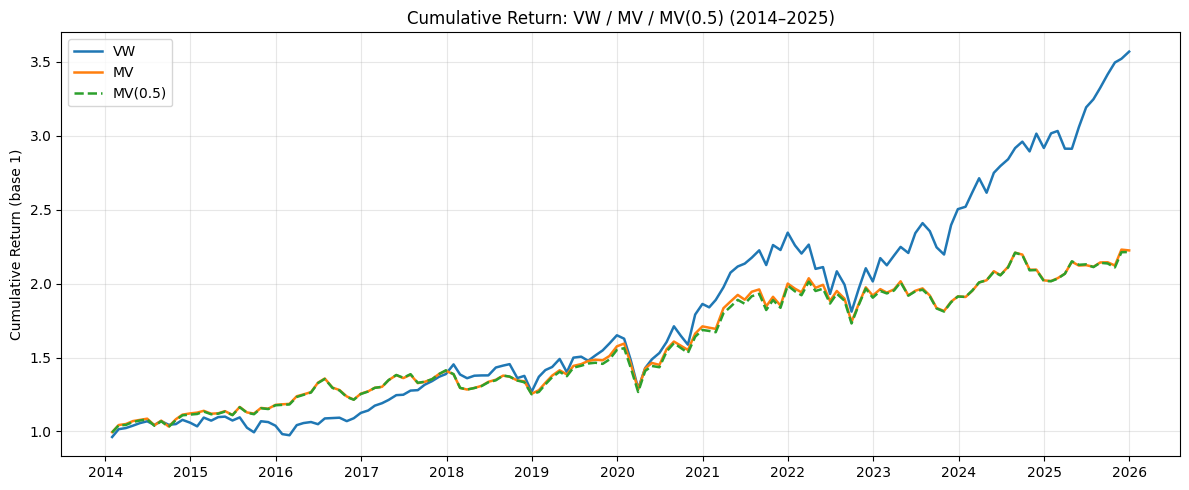

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2014,-0.006542,0.047761,0.003245,0.018828,0.009753,0.006968,-0.040068,0.029578,-0.03611,0.045716,0.029451,0.004114
2015,0.003832,0.014703,-0.016222,0.003489,0.01286,-0.021277,0.048069,-0.031957,-0.008783,0.036061,-0.004637,0.022143
2016,0.002162,0.002613,0.042748,0.011465,0.012728,0.050712,0.02098,-0.044961,-0.012982,-0.03496,-0.01473,0.031683
2017,0.013717,0.019373,0.005113,0.035224,0.025464,-0.013336,0.017608,-0.041837,0.00514,0.012605,0.026312,0.017833
2018,-0.018158,-0.066741,-0.008781,0.007739,0.010496,0.019396,0.01001,0.024132,-0.005335,-0.019455,-0.008731,-0.060768
2019,0.012461,0.040601,0.036515,0.026879,-0.021201,0.042018,0.00883,0.010572,0.003651,-0.005293,0.020515,0.04336
2020,0.007647,-0.084156,-0.115164,0.112505,0.02367,-0.005808,0.074595,0.036214,-0.020458,-0.021154,0.0714,0.027812
2021,-0.00396,-0.00504,0.07656,0.024339,0.025459,-0.013977,0.027288,0.008597,-0.056699,0.036993,-0.027836,0.08192
2022,-0.019571,-0.013559,0.047568,-0.031188,0.007838,-0.050978,0.035698,-0.024605,-0.081647,0.072689,0.059491,-0.031494
2023,0.023957,-0.008566,0.010368,0.028516,-0.045114,0.01512,0.005702,-0.023026,-0.042756,-0.011371,0.034721,0.020667


In [100]:
# ── Section 3.2: P(mv)(0.5) — min-variance with CF ≤ 0.5 × CF(MV) ──
#
# For each year Y, we solve:
#   min  α' Σ α
#   s.t. Σ_i α_i / Cap_i * E_i  ≤  0.5 × CF(MV)_Y
#        Σ_i α_i = 1
#        α_i ≥ 0
#
# CF here is normalised per M USD invested, so the constraint is purely on weights.

mv05_returns_fa  = {}
mv05_weights_fa  = {}
mv05_waci, mv05_cf = {}, {}

for year in range(2014, 2026):
    estimation_year = year - 1
    is_est      = globals()[f'is_{estimation_year}_fa']
    carbon_info = get_carbon_info(estimation_year)

    non_ret_cols = ['ISIN', 'NAME', 'Country', 'Region', 'MV_Y', 'MV_Y_weight',
                    'CO2_S1', 'CO2_S2', 'REV', 'CI']
    ret_cols_est = [c for c in is_est.columns if c not in non_ret_cols]

    R_mat = is_est.set_index('ISIN')[ret_cols_est].T.astype(float)
    R_mat = R_mat.dropna(how='all').fillna(0)
    isins_est = R_mat.columns.tolist()
    N = len(isins_est)

    # Ledoit-Wolf covariance
    lw = LedoitWolf()
    lw.fit(R_mat.values)
    Sigma = lw.covariance_

    # Carbon footprint vector: c_i = E_i / Cap_i  (per M USD invested)
    c_vec = np.array([
        carbon_info.loc[isin, 'E'] / carbon_info.loc[isin, 'MV_Y']
        if isin in carbon_info.index else 0.0
        for isin in isins_est
    ])

    # CF target = 0.5 × CF(MV) for this year
    cf_mv_target = mv_cf[year] * 0.5

    # Optimisation
    alpha0 = np.ones(N) / N

    def port_var_05(alpha):
        return alpha @ Sigma @ alpha

    def port_var_grad_05(alpha):
        return 2 * Sigma @ alpha

    constraints_05 = [
        {'type': 'eq',  'fun': lambda a: np.sum(a) - 1},
        {'type': 'ineq','fun': lambda a: cf_mv_target - a @ c_vec},   # CF ≤ target
    ]
    bounds = [(0, None)] * N

    res = minimize(port_var_05, alpha0,
                   jac=port_var_grad_05,
                   method='SLSQP',
                   bounds=bounds,
                   constraints=constraints_05,
                   options={'ftol': 1e-12, 'maxiter': 2000})

    alpha_opt = np.maximum(res.x, 0)
    alpha_opt /= alpha_opt.sum()

    mv05_weights_fa[estimation_year] = dict(zip(isins_est, alpha_opt))

    # Carbon metrics at portfolio construction date
    w_s = pd.Series(dict(zip(isins_est, alpha_opt)))
    isins_common = [i for i in isins_est if i in carbon_info.index]
    w_c   = w_s.loc[isins_common]
    ci_c  = carbon_info.loc[isins_common, 'CI']
    e_c   = carbon_info.loc[isins_common, 'E']
    cap_c = carbon_info.loc[isins_common, 'MV_Y']
    mv05_waci[year] = (w_c * ci_c).sum()
    mv05_cf[year]   = (w_c / cap_c * e_c).sum()

    # Out-of-sample returns for year Y
    is_next    = globals()[f'is_{year}']
    ret_cols_n = list(is_next.columns[-12:])
    ret_next   = is_next.set_index('ISIN')[ret_cols_n].astype(float)

    alpha_t = np.array([mv05_weights_fa[estimation_year].get(isin, 0.0)
                        for isin in ret_next.index])
    monthly_returns = {}
    for ret_col in sorted(ret_cols_n, key=lambda c: pd.to_datetime(c)):
        r_vec = ret_next[ret_col].fillna(0).values
        R_p   = float(alpha_t @ r_vec)
        monthly_returns[ret_col] = R_p
        alpha_t = alpha_t * (1 + r_vec) / (1 + R_p)
        alpha_t = np.maximum(alpha_t, 0)
        if alpha_t.sum() > 0:
            alpha_t /= alpha_t.sum()

    mv05_returns_fa[year] = pd.Series(monthly_returns)

    cf_achieved = alpha_opt @ c_vec
    print(f"Y={year} | N={N} | Opt={'OK' if res.success else 'FAIL'} | "
          f"CF(MV)={mv_cf[year]:.1f} | CF target={cf_mv_target:.1f} | CF achieved={cf_achieved:.1f}")

mv05_portfolio_returns_fa_df = create_returns_dataframe(mv05_returns_fa)

# Summary stats
stats_mv05 = portfolio_stats(mv05_returns_fa, rf)
stats_comparison = pd.DataFrame(
    [stats_vw, stats_mv, stats_mv05],
    index=['VW', 'MV', 'MV(0.5)']
).T.round(4)
print("\n=== Summary Statistics — VW / MV / MV(0.5) ===")
print(stats_comparison.to_string())

# Cumulative returns
cum_mv05 = cumulative_series(mv05_returns_fa)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum_vw.index,  cum_vw.values,  label='VW',       linewidth=1.8)
ax.plot(cum_mv.index,  cum_mv.values,  label='MV',       linewidth=1.8)
ax.plot(cum_mv05.index,cum_mv05.values,label='MV(0.5)',  linewidth=1.8, linestyle='--')
ax.set_title('Cumulative Return: VW / MV / MV(0.5) (2014–2025)')
ax.set_ylabel('Cumulative Return (base 1)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mv05_portfolio_returns_fa_df


### 3.3 Tracking-Error Minimisation with 50% CF Reduction — P(vw)(0.5)

Y=2014 | N=751 | Opt=OK | CF(VW)=178.5 | CF target=89.3 | CF achieved=89.3
Y=2015 | N=795 | Opt=OK | CF(VW)=156.2 | CF target=78.1 | CF achieved=78.1
Y=2016 | N=846 | Opt=OK | CF(VW)=151.3 | CF target=75.6 | CF achieved=75.6
Y=2017 | N=878 | Opt=OK | CF(VW)=160.5 | CF target=80.3 | CF achieved=80.3
Y=2018 | N=914 | Opt=OK | CF(VW)=137.5 | CF target=68.7 | CF achieved=68.7
Y=2019 | N=968 | Opt=OK | CF(VW)=110.5 | CF target=55.3 | CF achieved=55.3
Y=2020 | N=1062 | Opt=OK | CF(VW)=112.0 | CF target=56.0 | CF achieved=56.0
Y=2021 | N=1109 | Opt=OK | CF(VW)=86.4 | CF target=43.2 | CF achieved=43.2
Y=2022 | N=1147 | Opt=OK | CF(VW)=79.7 | CF target=39.9 | CF achieved=39.9
Y=2023 | N=1147 | Opt=OK | CF(VW)=65.0 | CF target=32.5 | CF achieved=32.5
Y=2024 | N=1136 | Opt=OK | CF(VW)=67.6 | CF target=33.8 | CF achieved=33.8
Y=2025 | N=1120 | Opt=OK | CF(VW)=59.4 | CF target=29.7 | CF achieved=29.7

=== Summary Statistics — VW / VW(0.5) ===
                       VW   VW(0.5)
Ann. Return (%)   11

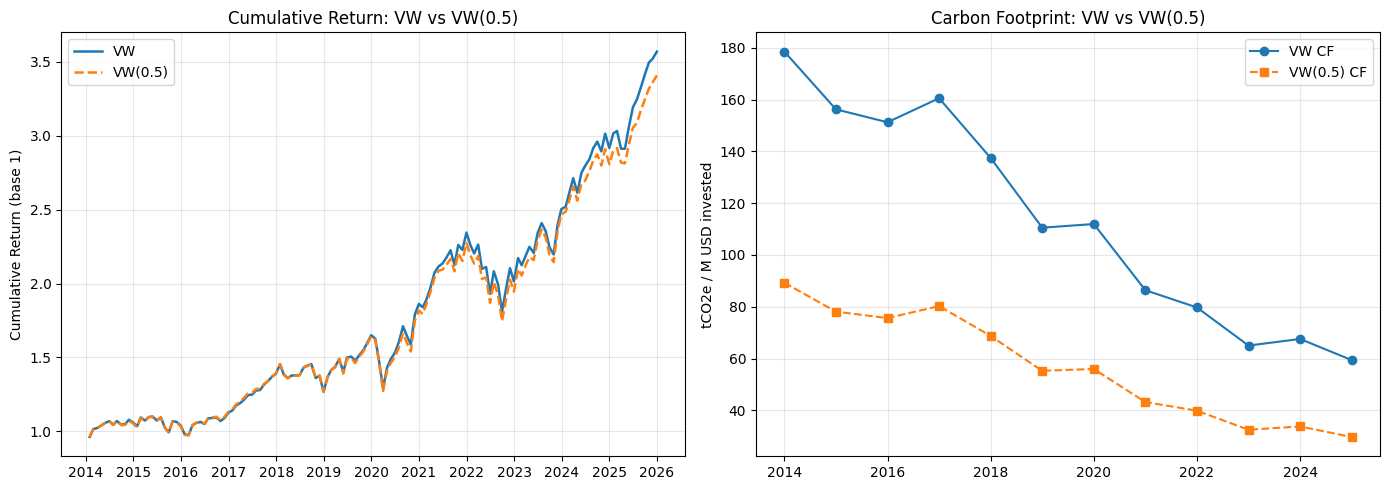

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2014,-0.03821,0.053981,0.007993,0.017823,0.015434,0.011242,-0.022078,0.023553,-0.025582,0.002368,0.026752,-0.018253
2015,-0.023205,0.059275,-0.018873,0.026058,0.000933,-0.023101,0.020228,-0.063481,-0.032843,0.076727,-0.006225,-0.024993
2016,-0.054868,-0.004407,0.072536,0.016317,0.005015,-0.013129,0.037314,0.003458,0.004276,-0.022702,0.021435,0.031705
2017,0.014965,0.02981,0.01461,0.02095,0.027775,0.000566,0.020934,0.000523,0.025871,0.015704,0.023026,0.01248
2018,0.047819,-0.049071,-0.01828,0.012204,0.000099,0.001908,0.038443,0.008342,0.006994,-0.062658,0.012143,-0.079944
2019,0.07933,0.034539,0.011315,0.04079,-0.066998,0.072783,0.003637,-0.023875,0.028431,0.023139,0.03109,0.035953
2020,-0.014168,-0.08867,-0.137764,0.106561,0.038287,0.026609,0.044317,0.060613,-0.038683,-0.03612,0.134347,0.039217
2021,-0.012347,0.034968,0.048468,0.047129,0.023749,0.003116,0.015023,0.019786,-0.038915,0.059198,-0.024541,0.056973
2022,-0.037524,-0.024855,0.024295,-0.071162,0.004836,-0.084023,0.07427,-0.04426,-0.090677,0.085498,0.069436,-0.039486
2023,0.078401,-0.021231,0.034353,0.025368,-0.009169,0.061902,0.031753,-0.022937,-0.050297,-0.022768,0.097642,0.048658


In [101]:
# ── Section 3.3: P(vw)(0.5) — tracking error minimisation, CF ≤ 0.5 × CF(VW) ──
#
# For each year Y, we solve:
#   min  (α - α_vw)' Σ (α - α_vw)
#   s.t. Σ_i α_i / Cap_i * E_i  ≤  0.5 × CF(VW)_Y
#        Σ_i α_i = 1
#        α_i ≥ 0

te05_returns_fa  = {}
te05_weights_fa  = {}
te05_waci, te05_cf = {}, {}

for year in range(2014, 2026):
    estimation_year = year - 1
    is_est      = globals()[f'is_{estimation_year}_fa']
    vw_port     = globals()[f'value_weighted_portfolio_{year}_fa']
    carbon_info = get_carbon_info(estimation_year)

    non_ret_cols = ['ISIN', 'NAME', 'Country', 'Region', 'MV_Y', 'MV_Y_weight',
                    'CO2_S1', 'CO2_S2', 'REV', 'CI']
    ret_cols_est = [c for c in is_est.columns if c not in non_ret_cols]

    R_mat = is_est.set_index('ISIN')[ret_cols_est].T.astype(float)
    R_mat = R_mat.dropna(how='all').fillna(0)
    isins_est = R_mat.columns.tolist()
    N = len(isins_est)

    # Ledoit-Wolf covariance
    lw = LedoitWolf()
    lw.fit(R_mat.values)
    Sigma = lw.covariance_

    # VW benchmark weights (aligned to estimation universe)
    vw_idx = vw_port.set_index('ISIN')['MV_Y_weight']
    alpha_vw = np.array([vw_idx.get(isin, 0.0) for isin in isins_est])
    alpha_vw /= alpha_vw.sum()

    # Carbon footprint vector
    c_vec = np.array([
        carbon_info.loc[isin, 'E'] / carbon_info.loc[isin, 'MV_Y']
        if isin in carbon_info.index else 0.0
        for isin in isins_est
    ])

    # CF target = 0.5 × CF(VW) for this year
    cf_vw_target = vw_cf[year] * 0.5

    # Optimisation: minimise tracking variance
    alpha0 = alpha_vw.copy()

    def te_var(alpha):
        diff = alpha - alpha_vw
        return diff @ Sigma @ diff

    def te_var_grad(alpha):
        return 2 * Sigma @ (alpha - alpha_vw)

    constraints_te = [
        {'type': 'eq',  'fun': lambda a: np.sum(a) - 1},
        {'type': 'ineq','fun': lambda a: cf_vw_target - a @ c_vec},
    ]
    bounds = [(0, None)] * N

    res = minimize(te_var, alpha0,
                   jac=te_var_grad,
                   method='SLSQP',
                   bounds=bounds,
                   constraints=constraints_te,
                   options={'ftol': 1e-12, 'maxiter': 2000})

    alpha_opt = np.maximum(res.x, 0)
    alpha_opt /= alpha_opt.sum()

    te05_weights_fa[estimation_year] = dict(zip(isins_est, alpha_opt))

    # Carbon metrics
    w_s = pd.Series(dict(zip(isins_est, alpha_opt)))
    isins_common = [i for i in isins_est if i in carbon_info.index]
    w_c   = w_s.loc[isins_common]
    ci_c  = carbon_info.loc[isins_common, 'CI']
    e_c   = carbon_info.loc[isins_common, 'E']
    cap_c = carbon_info.loc[isins_common, 'MV_Y']
    te05_waci[year] = (w_c * ci_c).sum()
    te05_cf[year]   = (w_c / cap_c * e_c).sum()

    # Out-of-sample returns
    is_next    = globals()[f'is_{year}']
    ret_cols_n = list(is_next.columns[-12:])
    ret_next   = is_next.set_index('ISIN')[ret_cols_n].astype(float)

    alpha_t = np.array([te05_weights_fa[estimation_year].get(isin, 0.0)
                        for isin in ret_next.index])
    monthly_returns = {}
    for ret_col in sorted(ret_cols_n, key=lambda c: pd.to_datetime(c)):
        r_vec = ret_next[ret_col].fillna(0).values
        R_p   = float(alpha_t @ r_vec)
        monthly_returns[ret_col] = R_p
        alpha_t = alpha_t * (1 + r_vec) / (1 + R_p)
        alpha_t = np.maximum(alpha_t, 0)
        if alpha_t.sum() > 0:
            alpha_t /= alpha_t.sum()

    te05_returns_fa[year] = pd.Series(monthly_returns)

    cf_achieved = alpha_opt @ c_vec
    print(f"Y={year} | N={N} | Opt={'OK' if res.success else 'FAIL'} | "
          f"CF(VW)={vw_cf[year]:.1f} | CF target={cf_vw_target:.1f} | CF achieved={cf_achieved:.1f}")

te05_portfolio_returns_fa_df = create_returns_dataframe(te05_returns_fa)

# Summary stats
stats_te05 = portfolio_stats(te05_returns_fa, rf)
stats_comp2 = pd.DataFrame(
    [stats_vw, stats_te05],
    index=['VW', 'VW(0.5)']
).T.round(4)
print("\n=== Summary Statistics — VW / VW(0.5) ===")
print(stats_comp2.to_string())

# Carbon comparison table
carbon_te_table = pd.DataFrame({
    'VW WACI':      pd.Series(vw_waci),
    'VW(0.5) WACI': pd.Series(te05_waci),
    'VW CF':        pd.Series(vw_cf),
    'VW(0.5) CF':   pd.Series(te05_cf),
}).round(2)
print("\n=== WACI and CF: VW vs VW(0.5) ===")
print(carbon_te_table.to_string())

cum_te05 = cumulative_series(te05_returns_fa)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(cum_vw.index,  cum_vw.values,  label='VW',       linewidth=1.8)
axes[0].plot(cum_te05.index,cum_te05.values,label='VW(0.5)', linewidth=1.8, linestyle='--')
axes[0].set_title('Cumulative Return: VW vs VW(0.5)')
axes[0].set_ylabel('Cumulative Return (base 1)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].legend(); axes[0].grid(True, alpha=0.3)

years_list = sorted(vw_cf.keys())
axes[1].plot(years_list, [vw_cf[y] for y in years_list],   marker='o', label='VW CF')
axes[1].plot(years_list, [te05_cf[y] for y in years_list], marker='s', label='VW(0.5) CF', linestyle='--')
axes[1].set_title('Carbon Footprint: VW vs VW(0.5)')
axes[1].set_ylabel('tCO2e / M USD invested')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

te05_portfolio_returns_fa_df


### 3.4 Comparison of Portfolios

=== Summary Statistics — All Portfolios (2014–2025) ===
                       VW        MV   MV(0.5)   VW(0.5)
Ann. Return (%)   11.6586    7.3572    7.3041   11.2889
Ann. Vol (%)      14.2510   11.6522   11.5536   14.3792
Sharpe Ratio       0.6949    0.4774    0.4769    0.6630
Min Monthly (%)  -13.0817  -12.0684  -11.5164  -13.7764
Max Monthly (%)   12.8596   11.1593   11.2505   13.4347
Cum. Return (%)  256.8483  122.4169  121.3435  240.7329

=== Carbon Footprint and WACI — All Portfolios ===
       VW CF   MV CF  MV(0.5) CF  VW(0.5) CF  VW WACI  MV WACI  MV(0.5) WACI  VW(0.5) WACI
2014  178.54  390.47      195.23       89.27   196.63   772.40        345.80        117.33
2015  156.24  311.19      155.59       78.12   186.46   603.15        277.09        108.98
2016  151.26  199.65       99.82       75.63   197.40   433.97        188.54        118.94
2017  160.54  163.70       81.85       80.27   199.53   363.09        145.68        122.76
2018  137.45  167.72       83.86       68.73 

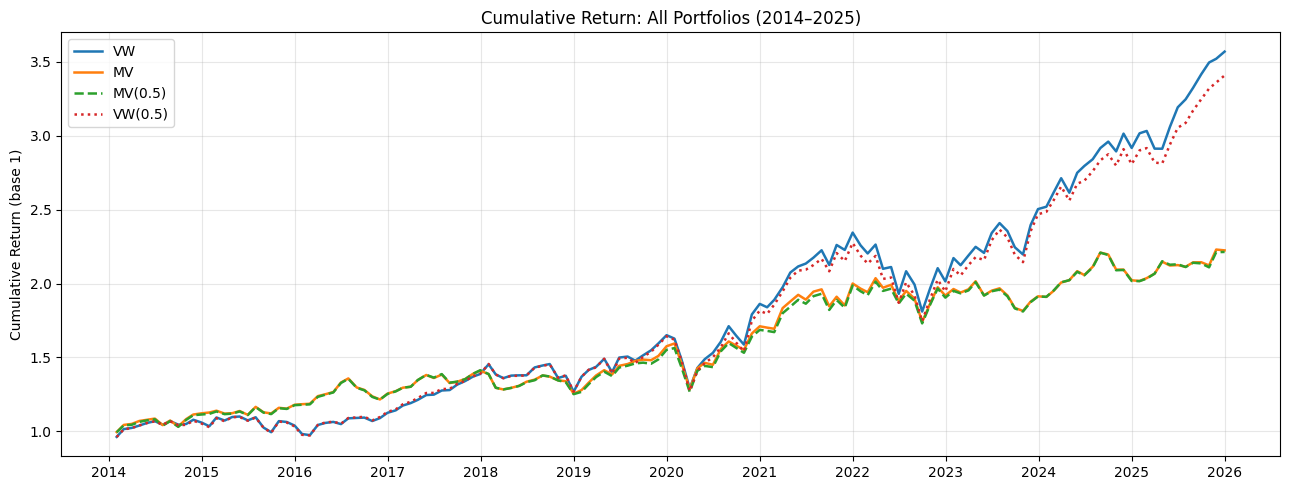

,VW,MV,MV(0.5),VW(0.5)
Ann. Return (%),11.6586,7.3572,7.3041,11.2889
Ann. Vol (%),14.2510,11.6522,11.5536,14.3792
Sharpe Ratio,0.6949,0.4774,0.4769,0.6630
Min Monthly (%),-13.0817,-12.0684,-11.5164,-13.7764
Max Monthly (%),12.8596,11.1593,11.2505,13.4347
Cum. Return (%),256.8483,122.4169,121.3435,240.7329


In [102]:
# ── Section 3.4: Full comparison — VW, MV, MV(0.5), VW(0.5) ──

stats_all = pd.DataFrame(
    [stats_vw, stats_mv, stats_mv05, stats_te05],
    index=['VW', 'MV', 'MV(0.5)', 'VW(0.5)']
).T.round(4)

print("=== Summary Statistics — All Portfolios (2014–2025) ===")
print(stats_all.to_string())

carbon_all = pd.DataFrame({
    'VW CF':       pd.Series(vw_cf),
    'MV CF':       pd.Series(mv_cf),
    'MV(0.5) CF':  pd.Series(mv05_cf),
    'VW(0.5) CF':  pd.Series(te05_cf),
    'VW WACI':     pd.Series(vw_waci),
    'MV WACI':     pd.Series(mv_waci),
    'MV(0.5) WACI':pd.Series(mv05_waci),
    'VW(0.5) WACI':pd.Series(te05_waci),
}).round(2)
print("\n=== Carbon Footprint and WACI — All Portfolios ===")
print(carbon_all.to_string())

# Cumulative returns — all four
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(cum_vw.index,   cum_vw.values,   label='VW',        linewidth=1.8)
ax.plot(cum_mv.index,   cum_mv.values,   label='MV',        linewidth=1.8)
ax.plot(cum_mv05.index, cum_mv05.values, label='MV(0.5)',   linewidth=1.8, linestyle='--')
ax.plot(cum_te05.index, cum_te05.values, label='VW(0.5)',   linewidth=1.8, linestyle=':')
ax.set_title('Cumulative Return: All Portfolios (2014–2025)')
ax.set_ylabel('Cumulative Return (base 1)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

stats_all


---
## Part II — Section 4: Net-Zero Portfolio

### 4.1 Net-Zero Portfolio — P(vw)(NZ)


In [103]:
# ── Section 4.1: P(vw)(NZ) — tracking error, CF reduced by 10% p.a. cumulatively ──
#
# CF target for year Y:
#   CF(p)_Y ≤ (1 - 0.10)^{Y - 2013} × CF(P(vw))_{2013}
#
# Y=2013 is the first portfolio construction year → Y-Y0+1 power in the spec.
# We use Y0=2013, so for Y=2013: factor = (0.9)^1 = 0.9
#                               Y=2014: factor = (0.9)^2 = 0.81  etc.
#
# Note: CF(VW)_2013 uses the estimation universe from is_2012_fa — but since
# we start allocation from 2014, the first CF reference is CF(VW) at Y=2013
# (the initial portfolio construction year), i.e. vw_cf[2014] computed above
# from the is_2013_fa universe. Following the spec literally:
#   CF(p)_Y ≤ (1-θ)^{Y-Y0+1} × CF(P(vw))_{Y0}
# where CF(P(vw))_{Y0} = CF(VW) at Y0=2013 construction ≡ vw_cf[2014].

theta   = 0.10
Y0      = 2013
cf_vw_Y0 = vw_cf[2014]   # CF of VW benchmark at Y0 construction (applied to 2014)

nz_returns_fa  = {}
nz_weights_fa  = {}
nz_waci, nz_cf = {}, {}

for year in range(2014, 2026):
    estimation_year = year - 1
    is_est      = globals()[f'is_{estimation_year}_fa']
    vw_port     = globals()[f'value_weighted_portfolio_{year}_fa']
    carbon_info = get_carbon_info(estimation_year)

    non_ret_cols = ['ISIN', 'NAME', 'Country', 'Region', 'MV_Y', 'MV_Y_weight',
                    'CO2_S1', 'CO2_S2', 'REV', 'CI']
    ret_cols_est = [c for c in is_est.columns if c not in non_ret_cols]

    R_mat = is_est.set_index('ISIN')[ret_cols_est].T.astype(float)
    R_mat = R_mat.dropna(how='all').fillna(0)
    isins_est = R_mat.columns.tolist()
    N = len(isins_est)

    # Ledoit-Wolf covariance
    lw = LedoitWolf()
    lw.fit(R_mat.values)
    Sigma = lw.covariance_

    # VW benchmark weights
    vw_idx   = vw_port.set_index('ISIN')['MV_Y_weight']
    alpha_vw = np.array([vw_idx.get(isin, 0.0) for isin in isins_est])
    alpha_vw /= alpha_vw.sum()

    # Carbon footprint vector
    c_vec = np.array([
        carbon_info.loc[isin, 'E'] / carbon_info.loc[isin, 'MV_Y']
        if isin in carbon_info.index else 0.0
        for isin in isins_est
    ])

    # Net-zero CF target: (1-θ)^{Y-Y0+1} × CF(VW)_{Y0}
    # For Y=2014 (first portfolio year): exponent = 2014-2013+1 = 2
    # Matches spec where the reduction starts immediately (factor < 1 from year 1)
    exponent   = year - Y0 + 1
    cf_nz_target = (1 - theta) ** exponent * cf_vw_Y0

    # Optimisation
    alpha0 = alpha_vw.copy()

    def te_var_nz(alpha):
        diff = alpha - alpha_vw
        return diff @ Sigma @ diff

    def te_var_grad_nz(alpha):
        return 2 * Sigma @ (alpha - alpha_vw)

    constraints_nz = [
        {'type': 'eq',  'fun': lambda a: np.sum(a) - 1},
        {'type': 'ineq','fun': lambda a: cf_nz_target - a @ c_vec},
    ]
    bounds = [(0, None)] * N

    res = minimize(te_var_nz, alpha0,
                   jac=te_var_grad_nz,
                   method='SLSQP',
                   bounds=bounds,
                   constraints=constraints_nz,
                   options={'ftol': 1e-12, 'maxiter': 2000})

    alpha_opt = np.maximum(res.x, 0)
    alpha_opt /= alpha_opt.sum()

    nz_weights_fa[estimation_year] = dict(zip(isins_est, alpha_opt))

    # Carbon metrics
    w_s = pd.Series(dict(zip(isins_est, alpha_opt)))
    isins_common = [i for i in isins_est if i in carbon_info.index]
    w_c   = w_s.loc[isins_common]
    ci_c  = carbon_info.loc[isins_common, 'CI']
    e_c   = carbon_info.loc[isins_common, 'E']
    cap_c = carbon_info.loc[isins_common, 'MV_Y']
    nz_waci[year] = (w_c * ci_c).sum()
    nz_cf[year]   = (w_c / cap_c * e_c).sum()

    # Out-of-sample returns
    is_next    = globals()[f'is_{year}']
    ret_cols_n = list(is_next.columns[-12:])
    ret_next   = is_next.set_index('ISIN')[ret_cols_n].astype(float)

    alpha_t = np.array([nz_weights_fa[estimation_year].get(isin, 0.0)
                        for isin in ret_next.index])
    monthly_returns = {}
    for ret_col in sorted(ret_cols_n, key=lambda c: pd.to_datetime(c)):
        r_vec = ret_next[ret_col].fillna(0).values
        R_p   = float(alpha_t @ r_vec)
        monthly_returns[ret_col] = R_p
        alpha_t = alpha_t * (1 + r_vec) / (1 + R_p)
        alpha_t = np.maximum(alpha_t, 0)
        if alpha_t.sum() > 0:
            alpha_t /= alpha_t.sum()

    nz_returns_fa[year] = pd.Series(monthly_returns)

    cf_achieved = alpha_opt @ c_vec
    print(f"Y={year} | exp={exponent} | CF(VW_Y0)={cf_vw_Y0:.1f} | "
          f"Target={cf_nz_target:.1f} | Achieved={cf_achieved:.1f} | "
          f"Opt={'OK' if res.success else 'FAIL'}")

nz_portfolio_returns_fa_df = create_returns_dataframe(nz_returns_fa)

stats_nz = portfolio_stats(nz_returns_fa, rf)

# Summary stats
stats_passive = pd.DataFrame(
    [stats_vw, stats_te05, stats_nz],
    index=['VW', 'VW(0.5)', 'VW(NZ)']
).T.round(4)
print("\n=== Summary Statistics — VW / VW(0.5) / VW(NZ) ===")
print(stats_passive.to_string())

nz_portfolio_returns_fa_df


Y=2014 | exp=2 | CF(VW_Y0)=178.5 | Target=144.6 | Achieved=144.6 | Opt=OK
Y=2015 | exp=3 | CF(VW_Y0)=178.5 | Target=130.2 | Achieved=130.2 | Opt=OK
Y=2016 | exp=4 | CF(VW_Y0)=178.5 | Target=117.1 | Achieved=117.1 | Opt=OK
Y=2017 | exp=5 | CF(VW_Y0)=178.5 | Target=105.4 | Achieved=105.4 | Opt=OK
Y=2018 | exp=6 | CF(VW_Y0)=178.5 | Target=94.9 | Achieved=94.9 | Opt=OK
Y=2019 | exp=7 | CF(VW_Y0)=178.5 | Target=85.4 | Achieved=85.4 | Opt=OK
Y=2020 | exp=8 | CF(VW_Y0)=178.5 | Target=76.9 | Achieved=76.9 | Opt=OK
Y=2021 | exp=9 | CF(VW_Y0)=178.5 | Target=69.2 | Achieved=69.2 | Opt=OK
Y=2022 | exp=10 | CF(VW_Y0)=178.5 | Target=62.3 | Achieved=62.3 | Opt=OK
Y=2023 | exp=11 | CF(VW_Y0)=178.5 | Target=56.0 | Achieved=56.0 | Opt=OK
Y=2024 | exp=12 | CF(VW_Y0)=178.5 | Target=50.4 | Achieved=50.4 | Opt=OK
Y=2025 | exp=13 | CF(VW_Y0)=178.5 | Target=45.4 | Achieved=45.4 | Opt=OK

=== Summary Statistics — VW / VW(0.5) / VW(NZ) ===
                       VW   VW(0.5)    VW(NZ)
Ann. Return (%)   11.6586 

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2014,-0.037645,0.054156,0.008546,0.018084,0.015332,0.011702,-0.022715,0.023554,-0.025134,0.002377,0.02681,-0.018176
2015,-0.023137,0.058487,-0.019205,0.025835,0.000758,-0.023653,0.019861,-0.063777,-0.032992,0.076721,-0.006313,-0.024778
2016,-0.054705,-0.003964,0.07279,0.016816,0.004459,-0.012233,0.037597,0.002981,0.004221,-0.021583,0.020995,0.031781
2017,0.014716,0.029967,0.014641,0.020663,0.028136,0.000568,0.021005,0.000867,0.025812,0.016093,0.022962,0.012328
2018,0.047643,-0.048896,-0.017938,0.012382,0.000008,0.001954,0.038438,0.008384,0.007034,-0.062627,0.012059,-0.079784
2019,0.07986,0.034128,0.011065,0.040766,-0.067274,0.072822,0.003502,-0.023908,0.028828,0.023163,0.030964,0.035969
2020,-0.013958,-0.089012,-0.137791,0.106293,0.038808,0.026258,0.044366,0.060661,-0.038365,-0.03578,0.133925,0.039137
2021,-0.012293,0.03554,0.048736,0.046855,0.023675,0.002809,0.014517,0.020126,-0.038642,0.059401,-0.024866,0.057285
2022,-0.036923,-0.024776,0.024823,-0.070233,0.005848,-0.084979,0.074444,-0.04337,-0.091045,0.085576,0.069242,-0.03947
2023,0.078154,-0.02144,0.035269,0.025063,-0.009403,0.062014,0.031834,-0.02349,-0.050331,-0.02269,0.097654,0.048312


### 4.2 Comparison of Passive Decarbonisation Portfolios

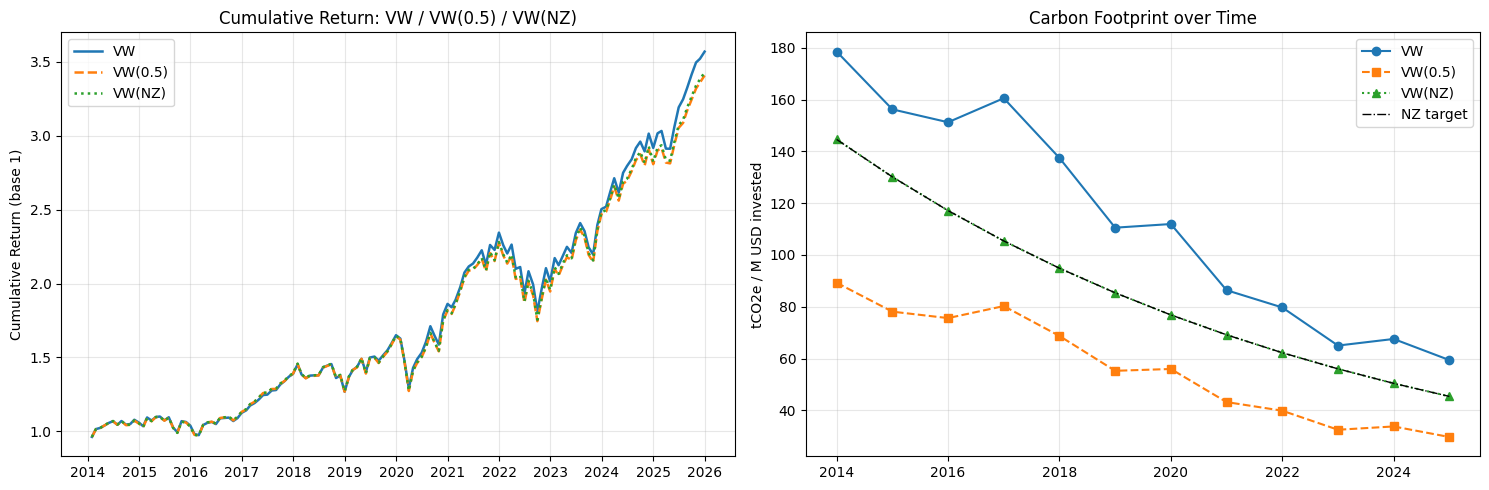

=== Carbon Footprint & WACI — Passive Strategies ===
       VW CF  VW(0.5) CF  VW(NZ) CF  NZ target  VW WACI  VW(0.5) WACI  VW(NZ) WACI
2014  178.54       89.27     144.62     144.62   196.63        117.33       171.00
2015  156.24       78.12     130.16     130.16   186.46        108.98       164.31
2016  151.26       75.63     117.14     117.14   197.40        118.94       171.00
2017  160.54       80.27     105.43     105.43   199.53        122.76       156.81
2018  137.45       68.73      94.88      94.88   210.45        130.86       168.15
2019  110.54       55.27      85.40      85.40   173.42        102.25       147.64
2020  111.95       55.98      76.86      76.86   178.17        102.86       139.20
2021   86.40       43.20      69.17      69.17   161.74         94.71       142.91
2022   79.74       39.87      62.25      62.25   159.54        100.54       138.51
2023   65.02       32.51      56.03      56.03   131.44         82.65       123.02
2024   67.57       33.79      50.4

,VW,MV,MV(0.5),VW(0.5),VW(NZ)
Ann. Return (%),11.6586,7.3572,7.3041,11.2889,11.3393
Ann. Vol (%),14.2510,11.6522,11.5536,14.3792,14.3737
Sharpe Ratio,0.6949,0.4774,0.4769,0.6630,0.6667
Min Monthly (%),-13.0817,-12.0684,-11.5164,-13.7764,-13.7791
Max Monthly (%),12.8596,11.1593,11.2505,13.4347,13.3925
Cum. Return (%),256.8483,122.4169,121.3435,240.7329,242.8082


In [104]:
# ── Section 4.2: VW, VW(0.5), VW(NZ) — cumulative returns and carbon ──

cum_nz = cumulative_series(nz_returns_fa)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Cumulative returns
axes[0].plot(cum_vw.index,  cum_vw.values,  label='VW',      linewidth=1.8)
axes[0].plot(cum_te05.index,cum_te05.values,label='VW(0.5)', linewidth=1.8, linestyle='--')
axes[0].plot(cum_nz.index,  cum_nz.values,  label='VW(NZ)',  linewidth=1.8, linestyle=':')
axes[0].set_title('Cumulative Return: VW / VW(0.5) / VW(NZ)')
axes[0].set_ylabel('Cumulative Return (base 1)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Carbon Footprint
years_list = sorted(vw_cf.keys())
axes[1].plot(years_list, [vw_cf[y] for y in years_list],    marker='o', label='VW')
axes[1].plot(years_list, [te05_cf[y] for y in years_list],  marker='s', label='VW(0.5)', linestyle='--')
axes[1].plot(years_list, [nz_cf[y] for y in years_list],    marker='^', label='VW(NZ)',  linestyle=':')
# Plot the net-zero target path
nz_targets = {y: (1 - theta)**(y - Y0 + 1) * cf_vw_Y0 for y in years_list}
axes[1].plot(years_list, [nz_targets[y] for y in years_list], color='black',
             linestyle='-.', linewidth=1, label='NZ target')
axes[1].set_title('Carbon Footprint over Time')
axes[1].set_ylabel('tCO2e / M USD invested')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Full carbon summary
carbon_passive = pd.DataFrame({
    'VW CF':      pd.Series(vw_cf),
    'VW(0.5) CF': pd.Series(te05_cf),
    'VW(NZ) CF':  pd.Series(nz_cf),
    'NZ target':  pd.Series(nz_targets),
    'VW WACI':    pd.Series(vw_waci),
    'VW(0.5) WACI': pd.Series(te05_waci),
    'VW(NZ) WACI':  pd.Series(nz_waci),
}).round(2)
print("=== Carbon Footprint & WACI — Passive Strategies ===")
print(carbon_passive.to_string())

# Final stats table
stats_final = pd.DataFrame(
    [stats_vw, stats_mv, stats_mv05, stats_te05, stats_nz],
    index=['VW', 'MV', 'MV(0.5)', 'VW(0.5)', 'VW(NZ)']
).T.round(4)
print("\n=== Final Summary Statistics — All Portfolios (2014–2025) ===")
print(stats_final.to_string())

stats_final
